In [ ]:
# Cell 1: Imports & Environment
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import ast  # For literal_eval of list strings

%matplotlib inline


In [ ]:
# Load CSV connectome
connectome_df = pd.read_csv("celegans_connectome_data/consensus_connectome_full_withfunc.csv")

# Load neural metadata
neural_df = pd.read_parquet("celegans_neural_data/worm_data_short.parquet")

# Normalize column names
connectome_df.columns = connectome_df.columns.str.strip().str.lower()
neural_df.columns = neural_df.columns.str.strip().str.lower()

# Preview
display(connectome_df.head(3))
display(neural_df.head(3))


In [4]:
# Cell 3: Build Graph with Synaptic and Functional Edge Attributes

G = nx.DiGraph()

for _, row in connectome_df.iterrows():
    src = row['from_neuron']
    tgt = row['to_neuron']
    
    # Use NaN-safe extraction for edge weights
    edge_attrs = {
        'chem_weight': row['mean_chem_weight'] if not pd.isna(row['mean_chem_weight']) else 0,
        'gap_weight': row['mean_gap_weight'] if not pd.isna(row['mean_gap_weight']) else 0,
        'functional_weight': row['functional_weight'] if not pd.isna(row['functional_weight']) else 0,
        'from_type': row['from_type'],
        'to_type': row['to_type'],
        'from_pos': row['from_pos'],
        'to_pos': row['to_pos'],
        'data_sources': ast.literal_eval(row['data_sources']) if isinstance(row['data_sources'], str) else []
    }

    # Add edge to graph
    G.add_edge(src, tgt, **edge_attrs)


In [5]:
# Cell 4: Add node attributes from neural_df

for _, row in neural_df.iterrows():
    neuron = row['neuron']
    
    if neuron in G.nodes:
        # Add all available metadata fields to node
        for key in row.index:
            G.nodes[neuron][key] = row[key]


In [6]:
# Cell 5: Basic Graph Diagnostics

print(f"Total neurons: {G.number_of_nodes()}")
print(f"Total synaptic connections: {G.number_of_edges()}")

# Degree stats
degrees = [d for _, d in G.degree()]
in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

print(f"Mean total degree: {np.mean(degrees):.2f}")
print(f"Mean in-degree: {np.mean(in_degrees):.2f}")
print(f"Mean out-degree: {np.mean(out_degrees):.2f}")

# Top hubs
top_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 neurons by out-degree (projectors):")
for neuron, deg in top_out:
    print(f"{neuron}: {deg}")


Total neurons: 300
Total synaptic connections: 90000
Mean total degree: 600.00
Mean in-degree: 300.00
Mean out-degree: 300.00

Top 10 neurons by out-degree (projectors):
ADAL: 300
ADAR: 300
ADEL: 300
ADER: 300
ADFL: 300
ADFR: 300
ADLL: 300
ADLR: 300
AFDL: 300
AFDR: 300


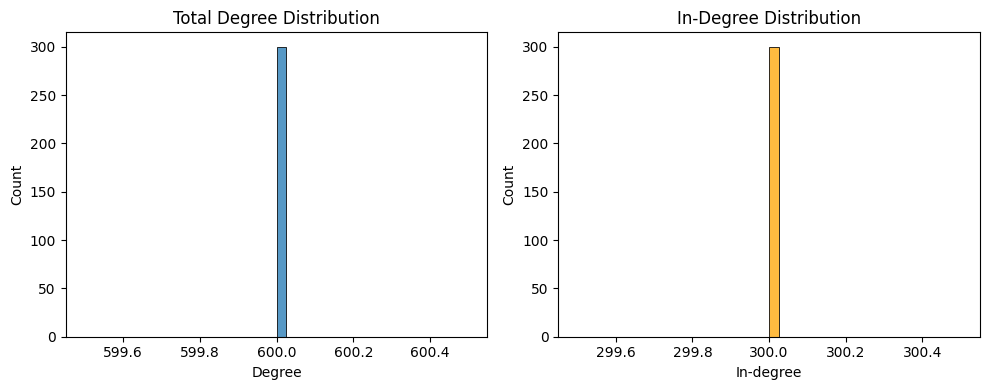

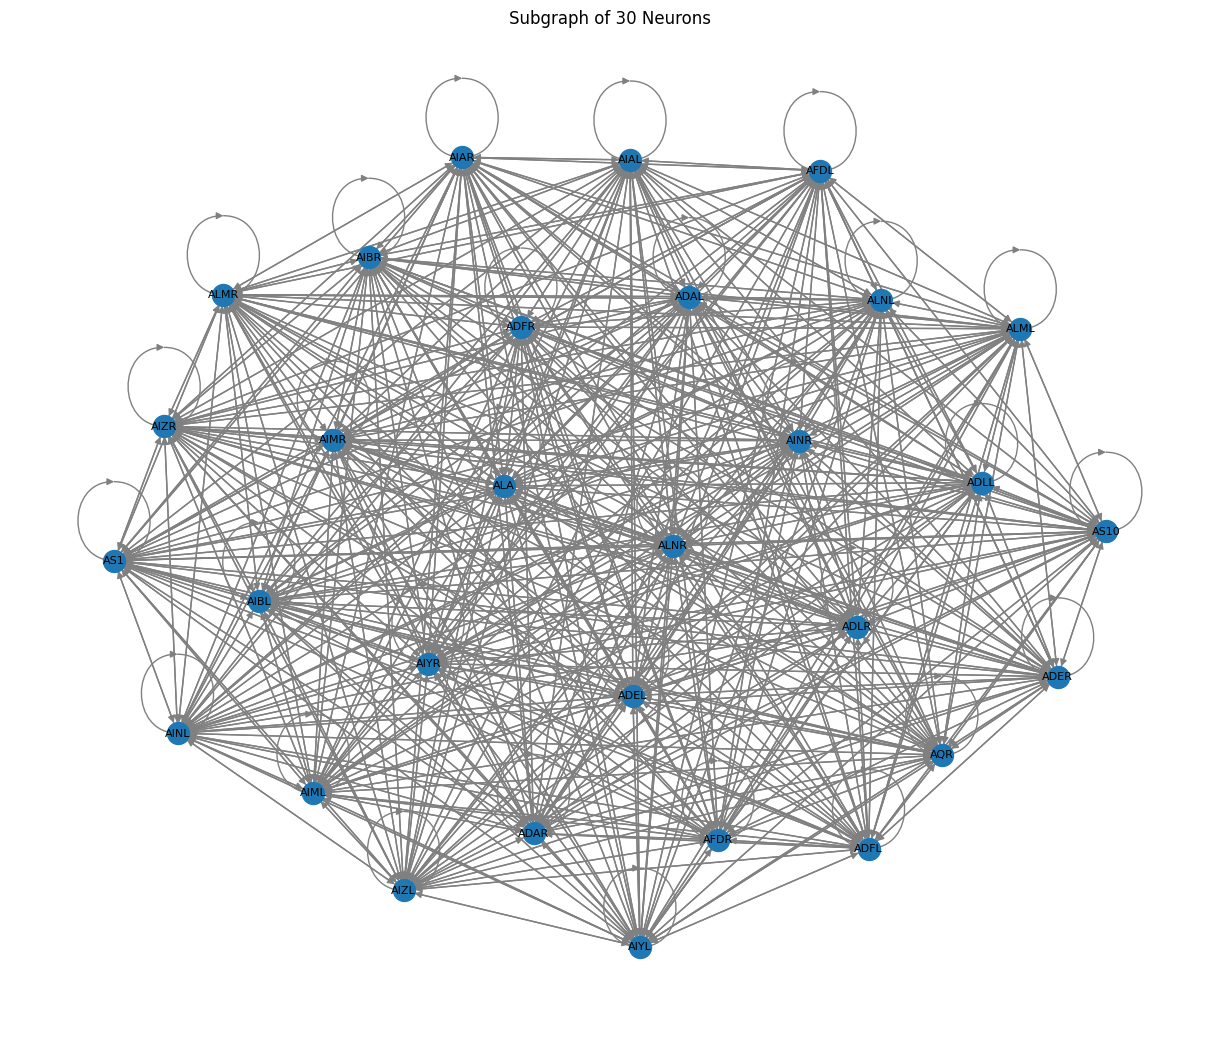

In [7]:
# Cell 6: Degree Histograms and Subgraph View

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(degrees, bins=40)
plt.title("Total Degree Distribution")
plt.xlabel("Degree")

plt.subplot(1, 2, 2)
sns.histplot(in_degrees, bins=40, color='orange')
plt.title("In-Degree Distribution")
plt.xlabel("In-degree")

plt.tight_layout()
plt.show()

# Plot a sample subgraph (first 30 nodes)
sub_nodes = list(G.nodes)[:30]
subG = G.subgraph(sub_nodes)

plt.figure(figsize=(12, 10))
nx.draw(
    subG,
    with_labels=True,
    node_size=250,
    font_size=8,
    edge_color='gray',
    arrows=True
)
plt.title("Subgraph of 30 Neurons")
plt.show()


In [8]:
# Cell 7: Save to GraphML (safe version without numpy arrays, lists, or custom types)

G_graphml = nx.DiGraph()

# Copy graph structure and only GraphML-compatible attributes
for u, v, d in G.edges(data=True):
    edge_attrs = {k: v for k, v in d.items() if isinstance(v, (str, int, float, bool))}
    G_graphml.add_edge(u, v, **edge_attrs)

for n, d in G.nodes(data=True):
    node_attrs = {k: v for k, v in d.items() if isinstance(v, (str, int, float, bool))}
    G_graphml.add_node(n, **node_attrs)

# Save
nx.write_graphml(G_graphml, "c_elegans_connectome_simplified.graphml")
print("Graph saved as c_elegans_connectome_simplified.graphml (with stripped attributes)")


Graph saved as c_elegans_connectome_simplified.graphml (with stripped attributes)


In [9]:
# Extract all unique symbolic seed neurons (e.g., sensory neurons)
symbolic_seeds = connectome_df[
    connectome_df['from_type'] == 'sensory'
]['from_neuron'].unique().tolist()

print(f"Identified {len(symbolic_seeds)} symbolic seed neurons (sensory)")
print(symbolic_seeds[:10])


Identified 85 symbolic seed neurons (sensory)
['ADEL', 'ADER', 'ADFL', 'ADFR', 'ADLL', 'ADLR', 'AFDL', 'AFDR', 'ALA', 'ALML']


In [11]:
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler

def extract_trace_features(trace):
    if not isinstance(trace, list) or len(trace) == 0:
        return {
            "mean": 0, "std": 0, "max": 0, "min": 0,
            "range": 0, "energy": 0, "skew": 0, "kurtosis": 0
        }
    x = np.array(trace)
    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "max": np.max(x),
        "min": np.min(x),
        "range": np.max(x) - np.min(x),
        "energy": np.sum(x**2),
        "skew": skew(x),
        "kurtosis": kurtosis(x)
    }

# Updated feature dict
neuron_features = {}

for neuron in G.nodes:
    degs = {
        "in_degree": G.in_degree(neuron),
        "out_degree": G.out_degree(neuron),
        "total_degree": G.degree(neuron),
        "has_trace": 0
    }
    neuron_features[neuron] = degs

for _, row in neural_df.iterrows():
    neuron = row['neuron']
    if neuron not in neuron_features:
        continue
    calcium = row['calcium_data']
    feats = extract_trace_features(calcium)
    neuron_features[neuron].update(feats)
    neuron_features[neuron]["has_trace"] = 1

features_df = pd.DataFrame.from_dict(neuron_features, orient='index').fillna(0)
scaler = StandardScaler()
features_df_scaled = pd.DataFrame(
    scaler.fit_transform(features_df),
    index=features_df.index,
    columns=features_df.columns
)

print("New feature matrix shape:", features_df_scaled.shape)
features_df_scaled.head()


New feature matrix shape: (300, 12)


,in_degree,out_degree,total_degree,has_trace,mean,std,max,min,range,energy,skew,kurtosis
ADAL,0.0,0.0,0.0,0.463222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADAR,0.0,0.0,0.0,0.463222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADEL,0.0,0.0,0.0,0.463222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADER,0.0,0.0,0.0,0.463222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ADFL,0.0,0.0,0.0,0.463222,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F


In [13]:
# Simple feedforward embedding model
class MLPProjector(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=32, output_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.encoder(x)


In [14]:
def get_top_functional_targets(seed_neuron, Z_norm, node_index, symbolic_seeds, k=5):
    """Given a symbolic neuron, return top-k functional targets that are not also symbolic"""
    s_idx = node_index.index(seed_neuron)
    s_vec = Z_norm[s_idx]
    
    # Functional candidates = all neurons not in symbolic seed list
    functional_idxs = [i for i, n in enumerate(node_index) if n not in symbolic_seeds]
    
    sims = torch.matmul(Z_norm[functional_idxs], s_vec)
    top_k = torch.topk(sims, k=k)

    targets = [node_index[functional_idxs[i]] for i in top_k.indices]
    return targets


In [15]:
import networkx as nx
import numpy as np
from collections import defaultdict

def simulate_signal(G, seeds, decay=0.8, threshold=0.1, steps=5):
    """
    Simulate signal propagation from seed neurons in G.
    - seeds: list of neuron names to activate
    - decay: how much signal drops each hop
    - threshold: minimum signal to continue propagating
    - steps: max steps to simulate
    """
    activation = defaultdict(float)
    for s in seeds:
        activation[s] = 1.0

    history = [dict(activation)]  # Track activation at each step

    for step in range(steps):
        new_activation = defaultdict(float)
        for node, signal in activation.items():
            if signal < threshold or node not in G:
                continue
            for neighbor in G.successors(node):
                weight = G[node][neighbor].get('weight', 1.0)
                new_signal = signal * decay * weight
                if new_signal > new_activation[neighbor]:
                    new_activation[neighbor] = new_signal
        activation = new_activation
        history.append(dict(activation))
    
    return history


In [16]:
symbolic_seed = "ADEL"
functional_targets = get_top_functional_targets(
    symbolic_seed, Z_norm, node_index, symbolic_seeds, k=5
)

print(f"\n{symbolic_seed} projected → {functional_targets}")

history = simulate_signal(G, functional_targets, decay=0.85, steps=6)

# Print results
for t, act in enumerate(history):
    top = sorted(act.items(), key=lambda x: -x[1])[:10]
    print(f"\nStep {t}:")
    for neuron, val in top:
        print(f"  {neuron:5} → {val:.3f}")


NameError: name 'Z_norm' is not defined

In [17]:
from collections import defaultdict
import numpy as np
from tqdm import tqdm

def simulate_projection_vector(G, seed, neuron_list, decay=0.85, threshold=0.01, steps=6):
    """
    Runs signal simulation from a seed neuron and returns a vector
    of activation scores over all neurons (in fixed order).
    """
    activation = defaultdict(float)
    activation[seed] = 1.0
    history = [dict(activation)]

    for _ in range(steps):
        new_activation = defaultdict(float)
        for node, signal in activation.items():
            if signal < threshold or node not in G:
                continue
            for neighbor in G.successors(node):
                weight = G[node][neighbor].get('functional_weight', 1.0)
                propagated = signal * decay * weight
                new_activation[neighbor] = max(new_activation[neighbor], propagated)
        activation = new_activation
        history.append(dict(activation))

    # Sum activations across all steps
    total = defaultdict(float)
    for step in history:
        for n, v in step.items():
            total[n] += v

    # Convert to ordered vector
    return np.array([total.get(n, 0.0) for n in neuron_list])

# Build the full projection matrix
neuron_list = sorted(list(G.nodes))
projection_vectors = {}

for neuron in tqdm(neuron_list, desc="Simulating projection vectors"):
    vec = simulate_projection_vector(G, neuron, neuron_list)
    # Optional: normalize each vector
    if np.linalg.norm(vec) > 0:
        vec = vec / np.linalg.norm(vec)
    projection_vectors[neuron] = vec


Simulating projection vectors: 100%|██████████| 300/300 [00:01<00:00, 202.39it/s]


In [22]:
import pandas as pd

# Load both Excel files
df1 = pd.read_excel("NeuronLineage_Part1.xls")
df2 = pd.read_excel("NeuronLineage_Part2.xls")

print("Part 1 columns:", df1.columns.tolist())
print("Part 2 columns:", df2.columns.tolist())



Part 1 columns: ['Neuron 1', 'Neuron 2', 'Relatedness']
Part 2 columns: ['Neuron 1', 'Neuron 2', 'Relatedness']


In [25]:
import pandas as pd
import numpy as np

# Load both parts
df1 = pd.read_excel("NeuronLineage_Part1.xls")
df2 = pd.read_excel("NeuronLineage_Part2.xls")

# Combine
df = pd.concat([df1, df2])
df = df.dropna()

# Standardize neuron names
df['Neuron 1'] = df['Neuron 1'].str.strip().str.upper()
df['Neuron 2'] = df['Neuron 2'].str.strip().str.upper()

# Get full neuron list
all_neurons = sorted(set(df['Neuron 1']).union(set(df['Neuron 2'])))
neuron_idx = {n: i for i, n in enumerate(all_neurons)}
N = len(all_neurons)

# Initialize distance matrix
lineage_distance_matrix = np.full((N, N), np.nan)

# Fill matrix
for _, row in df.iterrows():
    i = neuron_idx[row['Neuron 1']]
    j = neuron_idx[row['Neuron 2']]
    dist = row['Relatedness']
    lineage_distance_matrix[i, j] = lineage_distance_matrix[j, i] = dist

# Optional: normalize or invert distance
# If higher values mean "closer", we invert:
if lineage_distance_matrix[~np.isnan(lineage_distance_matrix)].mean() > 10:
    max_val = np.nanmax(lineage_distance_matrix)
    lineage_distance_matrix = max_val - lineage_distance_matrix

# Replace diagonal
np.fill_diagonal(lineage_distance_matrix, 0.0)


In [28]:
import pandas as pd
import numpy as np

# Load both parts
df1 = pd.read_excel("NeuronLineage_Part1.xls")
df2 = pd.read_excel("NeuronLineage_Part2.xls")

# Combine and clean
df = pd.concat([df1, df2])
df = df.dropna()
df['Neuron 1'] = df['Neuron 1'].str.strip().str.upper()
df['Neuron 2'] = df['Neuron 2'].str.strip().str.upper()

# Get all unique neurons
all_neurons = sorted(set(df['Neuron 1']).union(set(df['Neuron 2'])))
neuron_idx = {n: i for i, n in enumerate(all_neurons)}
N = len(all_neurons)

# Initialize empty matrix
lineage_distance_matrix = np.full((N, N), np.nan)

# Fill with relatedness scores
for _, row in df.iterrows():
    i = neuron_idx[row['Neuron 1']]
    j = neuron_idx[row['Neuron 2']]
    score = row['Relatedness']
    lineage_distance_matrix[i, j] = lineage_distance_matrix[j, i] = score

# Optional: invert so that higher = more distant (if needed)
mean_score = np.nanmean(lineage_distance_matrix)
if mean_score > 10:  # assumes high = close
    max_val = np.nanmax(lineage_distance_matrix)
    lineage_distance_matrix = max_val - lineage_distance_matrix

# Set self-distance = 0
np.fill_diagonal(lineage_distance_matrix, 0.0)

# ---- ✅ Confirm Outputs ---- #
print(f"✔️ Lineage matrix shape: {lineage_distance_matrix.shape}")
print(f"✔️ Example neurons: {all_neurons[:5]}")
print("✔️ Preview of lineage distance matrix (first 5x5 block):")
print(pd.DataFrame(lineage_distance_matrix[:5, :5], index=all_neurons[:5], columns=all_neurons[:5]))


✔️ Lineage matrix shape: (279, 279)
✔️ Example neurons: ['ADAL', 'ADAR', 'ADEL', 'ADER', 'ADFL']
✔️ Preview of lineage distance matrix (first 5x5 block):
      ADAL  ADAR  ADEL  ADER  ADFL
ADAL   0.0   8.0  24.0   8.0   7.0
ADAR   8.0   0.0   8.0  24.0   7.0
ADEL  24.0   8.0   0.0   8.0   7.0
ADER   8.0  24.0   8.0   0.0   7.0
ADFL   7.0   7.0   7.0   7.0   0.0


In [30]:
# Step 1: Find shared neurons
functional_neurons = set(projection_vectors.keys())
lineage_neurons = set(all_neurons)
shared_neurons = sorted(functional_neurons.intersection(lineage_neurons))

print(f"✔️ Shared neurons: {len(shared_neurons)}")

# Create mapping from neuron to index in lineage matrix
idx_map = {n: all_neurons.index(n) for n in shared_neurons}


✔️ Shared neurons: 216


In [31]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Step 2: Functional similarity matrix
func_mat = np.array([projection_vectors[n] for n in shared_neurons])
func_sim_matrix = cosine_similarity(func_mat)

# Step 3: Lineage distance matrix aligned
lin_dist_matrix = np.array([
    [lineage_distance_matrix[idx_map[a], idx_map[b]] for b in shared_neurons]
    for a in shared_neurons
])


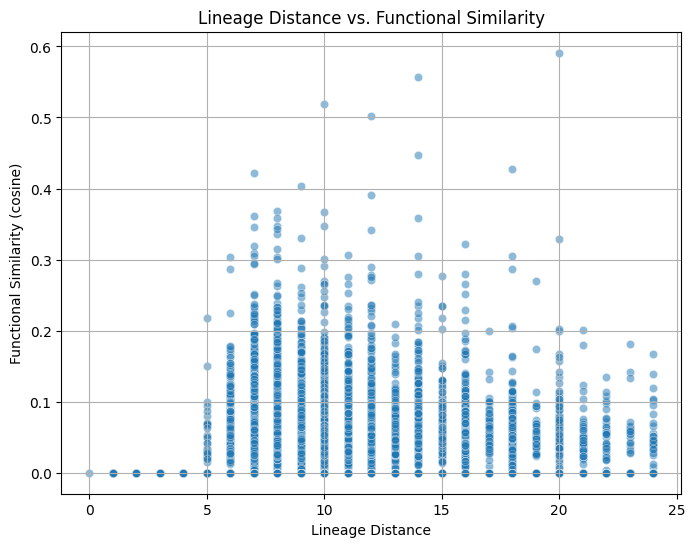

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 4: Correlation plot setup
triu = np.triu_indices(len(shared_neurons), k=1)
lineage_flat = lin_dist_matrix[triu]
funcsim_flat = func_sim_matrix[triu]

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=lineage_flat, y=funcsim_flat, alpha=0.5)
plt.title("Lineage Distance vs. Functional Similarity")
plt.xlabel("Lineage Distance")
plt.ylabel("Functional Similarity (cosine)")
plt.grid(True)
plt.show()


In [34]:
# Step 5: Compute Pearson correlation
corr = np.corrcoef(lineage_flat, funcsim_flat)[0, 1]
print(f"📈 Pearson correlation: {corr:.3f}")


📈 Pearson correlation: 0.157


/home/rohit/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/rohit/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/rohit/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/rohit/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


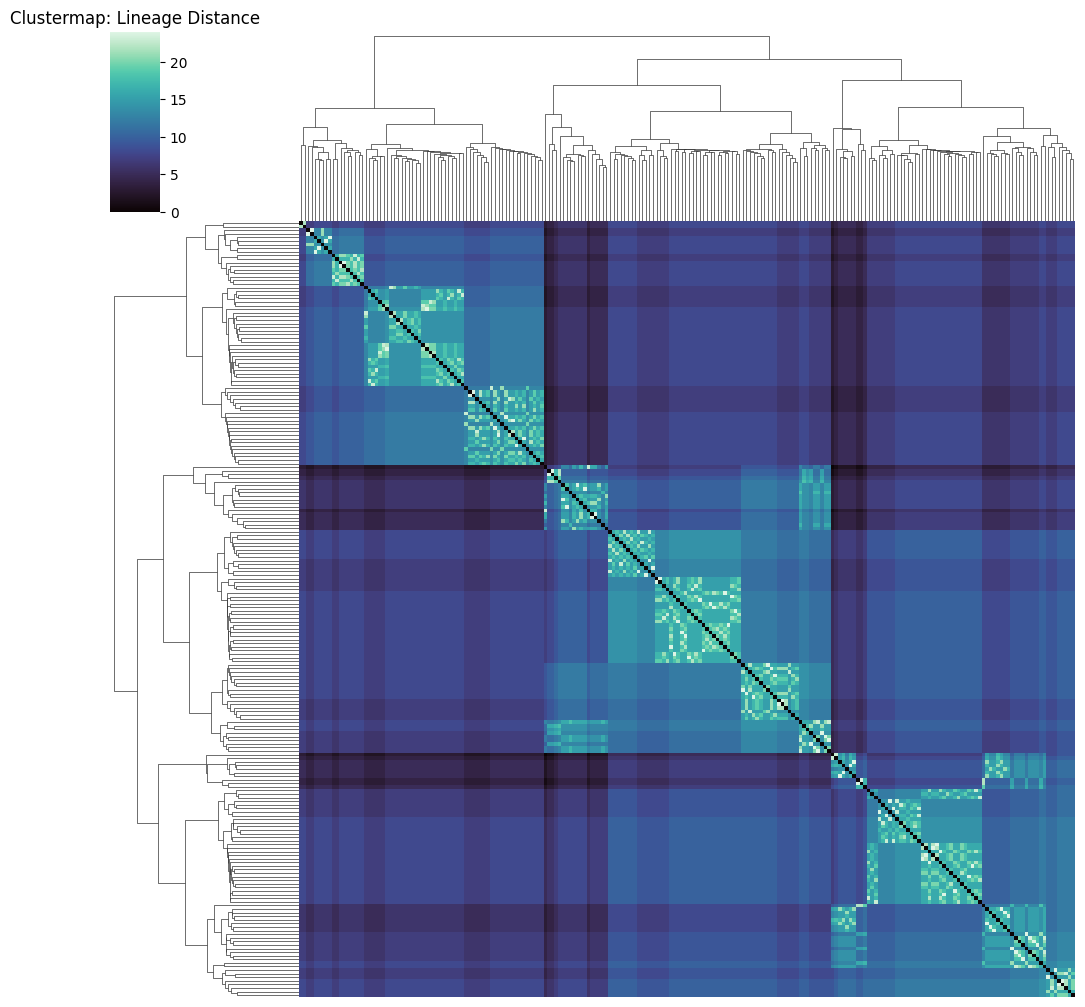

/home/rohit/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/rohit/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


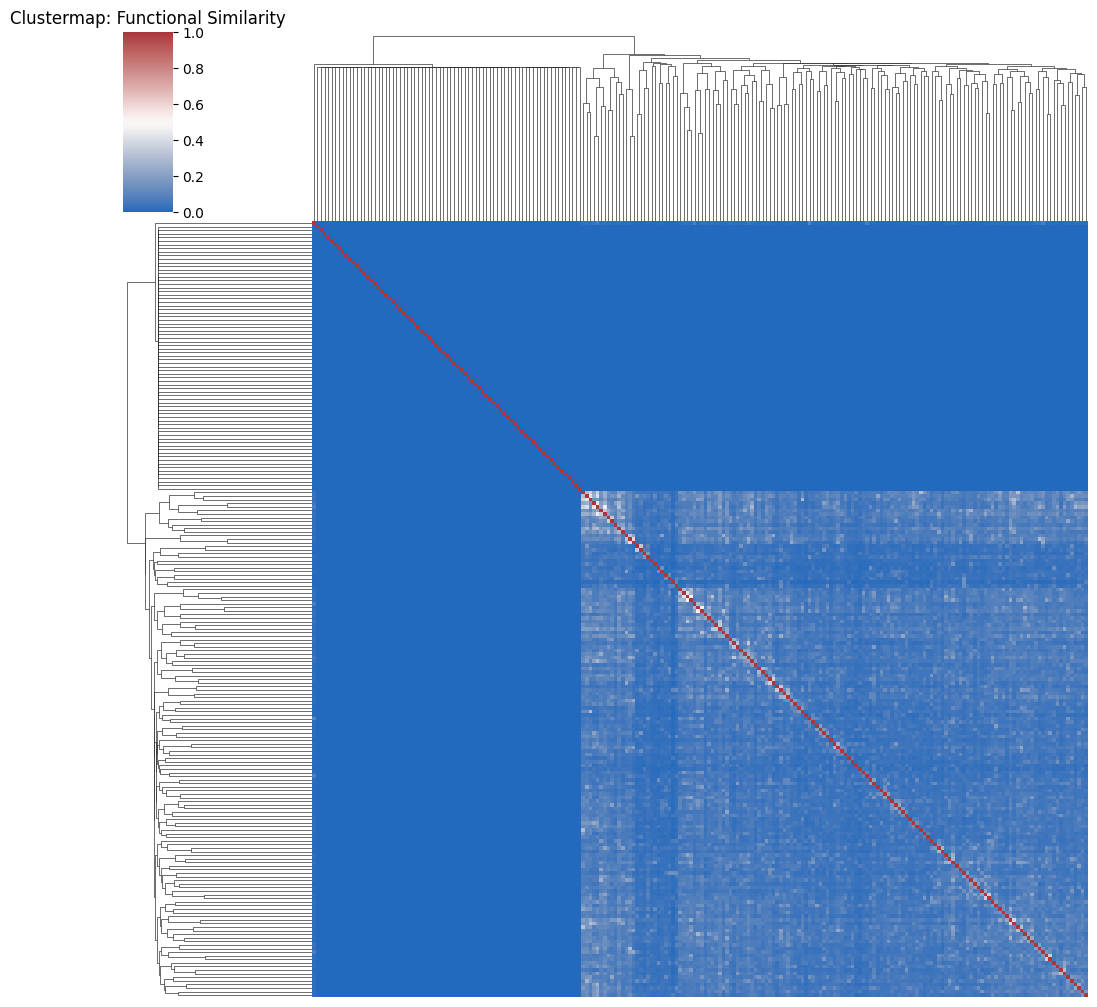

In [35]:
# Step 6: Clustermap of lineage distance
sns.clustermap(lin_dist_matrix, cmap='mako', xticklabels=False, yticklabels=False)
plt.title("Clustermap: Lineage Distance")
plt.show()

# Step 7: Clustermap of functional similarity
sns.clustermap(func_sim_matrix, cmap='vlag', xticklabels=False, yticklabels=False)
plt.title("Clustermap: Functional Similarity")
plt.show()


In [37]:
# --- Standard Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from itertools import combinations

# --- Safe UMAP Import (no TensorFlow) ---
try:
    import umap.umap_ as umap_module  # Patch: skip tensorflow/parametric_umap
    has_umap = True
    print("✅ UMAP (non-parametric) loaded.")
except Exception as e:
    has_umap = False
    print(f"⚠️  UMAP unavailable: {e}")

# --- Defensive Sanity Checks ---
assert isinstance(projection_vectors, dict) and len(projection_vectors) > 0, \
    "projection_vectors missing"
assert isinstance(lineage_distance_matrix, np.ndarray), "lineage matrix missing"

print("✅ All core data objects are present.")


⚠️  UMAP unavailable: module 'lib' has no attribute 'X509_V_FLAG_NOTIFY_POLICY'
✅ All core data objects are present.


In [38]:
# 1️⃣ neurons that appear in BOTH datasets
func_neurons = set(projection_vectors.keys())
line_neurons = set(all_neurons)
shared_neurons = sorted(func_neurons & line_neurons)
print(f"Shared neurons: {len(shared_neurons)}")

# 2️⃣ build aligned functional similarity matrix
func_mat = np.vstack([projection_vectors[n] for n in shared_neurons])
func_sim_mat = cosine_similarity(func_mat)

# 3️⃣ slice lineage matrix into the same order
row_idx = [all_neurons.index(n) for n in shared_neurons]
lin_dist_mat = lineage_distance_matrix[np.ix_(row_idx, row_idx)]

# symmetric sanity
assert np.allclose(lin_dist_mat, lin_dist_mat.T, equal_nan=True)


Shared neurons: 216


In [39]:
# upper-triangle indices
triu = np.triu_indices_from(func_sim_mat, k=1)
lineage_vals = lin_dist_mat[triu]
func_vals    = func_sim_mat[triu]

# percentile thresholds
high_func_thresh = np.percentile(func_vals, 95)  # top 5 %
far_line_thresh  = np.percentile(lineage_vals, 75)  # farthest 25 %

outlier_mask = (func_vals >= high_func_thresh) & (lineage_vals >= far_line_thresh)
outlier_idx  = np.where(outlier_mask)[0]

outliers = []
for idx in outlier_idx:
    i, j = triu[0][idx], triu[1][idx]
    outliers.append((shared_neurons[i], shared_neurons[j],
                     func_vals[idx], lineage_vals[idx]))

# sort by functional similarity desc
outliers.sort(key=lambda x: -x[2])

print(f"🔔 Outlier pairs (high function ∧ far lineage): {len(outliers)}")
print("Top 15:")
for a, b, f, l in outliers[:15]:
    print(f"{a:6s} – {b:6s} | func ≈ {f:.3f} | lineage ≈ {l:.1f}")


🔔 Outlier pairs (high function ∧ far lineage): 455
Top 15:
IL2DL  – URYDL  | func ≈ 0.591 | lineage ≈ 20.0
RIBL   – RIML   | func ≈ 0.557 | lineage ≈ 14.0
RIGL   – RMDR   | func ≈ 0.519 | lineage ≈ 10.0
AINL   – SAADL  | func ≈ 0.502 | lineage ≈ 12.0
AVKL   – RIML   | func ≈ 0.446 | lineage ≈ 14.0
AINL   – AVDL   | func ≈ 0.428 | lineage ≈ 18.0
IL2R   – RMDDL  | func ≈ 0.391 | lineage ≈ 12.0
BAGL   – SMDVR  | func ≈ 0.367 | lineage ≈ 10.0
IL2L   – RMEL   | func ≈ 0.358 | lineage ≈ 14.0
ADAR   – RICR   | func ≈ 0.348 | lineage ≈ 10.0
ASGL   – RIVL   | func ≈ 0.342 | lineage ≈ 12.0
RIBR   – RIVR   | func ≈ 0.330 | lineage ≈ 20.0
IL2DL  – IL2DR  | func ≈ 0.322 | lineage ≈ 16.0
ADAL   – RIML   | func ≈ 0.306 | lineage ≈ 11.0
AVDL   – AVHL   | func ≈ 0.305 | lineage ≈ 14.0


In [41]:
# Dynamically detect column names
possible_neuron_cols = [col for col in connectome_df.columns if "neuron" in col.lower()]
possible_type_cols   = [col for col in connectome_df.columns if "type" in col.lower()]

print(f"🧠 Found neuron columns: {possible_neuron_cols}")
print(f"🔎 Found type columns: {possible_type_cols}")

# Build neuron → class/type mapping
neuron_class = {}

# Try matching each neuron with a type column
for ncol in possible_neuron_cols:
    for tcol in possible_type_cols:
        try:
            for n, t in connectome_df[[ncol, tcol]].dropna().values:
                n = str(n).strip().upper()
                t = str(t).strip().lower()
                if n not in neuron_class:
                    neuron_class[n] = t
        except Exception as e:
            print(f"⚠️  Skipping pair {ncol}, {tcol} due to: {e}")

# Fallback default
for n in shared_neurons:
    neuron_class.setdefault(n, "unknown")

# Set up class → color map
class_palette = {"sensory": "tab:blue", "inter": "tab:green",
                 "motor": "tab:red", "unknown": "gray"}


🧠 Found neuron columns: ['from_neuron', 'to_neuron']
🔎 Found type columns: ['from_type', 'to_type']


In [42]:
# ---------- PCA ----------
scaler = StandardScaler()
X_std = scaler.fit_transform(func_mat)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)
print(f"PCA explained variance (2D): {pca.explained_variance_ratio_.sum():.2%}")

# ---------- UMAP (Non-Parametric Only) ----------
if has_umap:
    umap_model = umap_module.UMAP(n_neighbors=30, min_dist=0.3, metric='cosine', random_state=42)
    X_umap = umap_model.fit_transform(func_mat)


PCA explained variance (2D): 5.22%


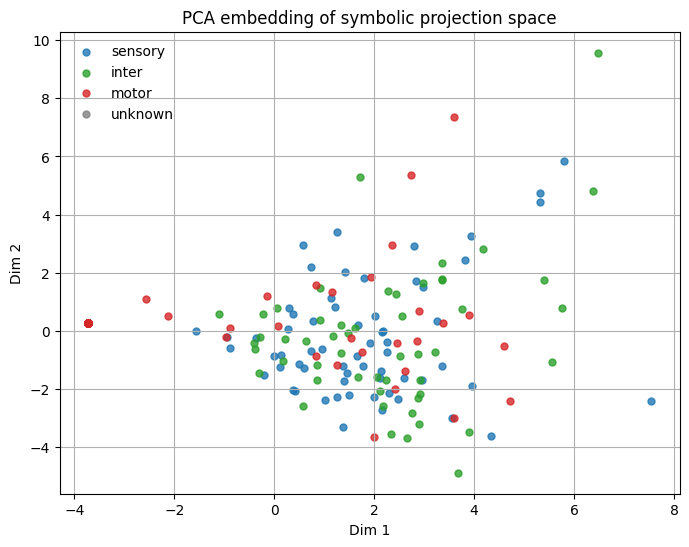

In [43]:
def plot_embedding(emb, title, alpha=0.8):
    plt.figure(figsize=(8, 6))
    for cls, color in class_palette.items():
        mask = [neuron_class[n] == cls for n in shared_neurons]
        plt.scatter(emb[mask, 0], emb[mask, 1],
                    s=25, alpha=alpha, label=cls, color=color)
    plt.legend(markerscale=1, frameon=False)
    plt.title(title)
    plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
    plt.grid(True); plt.show()

plot_embedding(X_pca, "PCA embedding of symbolic projection space")

if has_umap:
    plot_embedding(X_umap, "UMAP embedding of symbolic projection space")


In [48]:
from itertools import combinations

# Alias for clarity (if not already defined)
lineage_dist_matrix = lin_dist_matrix  # lin_dist_matrix is the aligned version you built earlier

# Step 1: List of neuron pairs
pair_indices = list(combinations(shared_neurons, 2))

# Step 2: Extract pairwise values
func_sim_values = []
lineage_dist_values = []

for n1, n2 in pair_indices:
    idx1, idx2 = shared_neurons.index(n1), shared_neurons.index(n2)
    func_sim = func_sim_matrix[idx1, idx2]
    lineage_dist = lineage_dist_matrix[idx1, idx2]
    func_sim_values.append(func_sim)
    lineage_dist_values.append(lineage_dist)

func_sim_values = np.array(func_sim_values)
lineage_dist_values = np.array(lineage_dist_values)

print(f"✅ Rebuilt {len(pair_indices)} pairwise values (func + lineage)")


✅ Rebuilt 23220 pairwise values (func + lineage)


In [49]:
# Thresholds
top_sim_thresh = np.percentile(func_sim_values, 95)     # Top 5% functional similarity
top_dist_thresh = np.percentile(lineage_dist_values, 75) # Top 25% lineage distance

# Extract top outliers: High function ∧ High lineage distance
top_outlier_pairs = [
    (n1, n2, sim, dist)
    for (n1, n2), sim, dist in zip(pair_indices, func_sim_values, lineage_dist_values)
    if sim >= top_sim_thresh and dist >= top_dist_thresh
]

# Sort by functional similarity descending
top_outlier_pairs.sort(key=lambda x: -x[2])

# Sanity check
print(f"✅ Loaded {len(top_outlier_pairs)} high-function, high-lineage outliers")
print("Top 5 examples:")
for entry in top_outlier_pairs[:5]:
    print(entry)


✅ Loaded 455 high-function, high-lineage outliers
Top 5 examples:
('IL2DL', 'URYDL', 0.591118377597569, 20.0)
('RIBL', 'RIML', 0.5567282572089817, 14.0)
('RIGL', 'RMDR', 0.5190166541729199, 10.0)
('AINL', 'SAADL', 0.5021203652087725, 12.0)
('AVKL', 'RIML', 0.4464909919488599, 14.0)


In [50]:
# Convert connectome edges into sets for fast lookup
input_map = {}
output_map = {}
direct_edges = set()

for _, row in connectome_df.dropna().iterrows():
    src = str(row['from_neuron']).strip().upper()
    tgt = str(row['to_neuron']).strip().upper()
    direct_edges.add((src, tgt))

    output_map.setdefault(src, set()).add(tgt)
    input_map.setdefault(tgt, set()).add(src)

def get_overlap_stats(n1, n2):
    # Shared inputs and outputs
    inputs_n1 = input_map.get(n1, set())
    inputs_n2 = input_map.get(n2, set())
    outputs_n1 = output_map.get(n1, set())
    outputs_n2 = output_map.get(n2, set())

    shared_inputs = inputs_n1.intersection(inputs_n2)
    shared_outputs = outputs_n1.intersection(outputs_n2)
    direct = (n1, n2) in direct_edges or (n2, n1) in direct_edges

    return {
        "shared_inputs": shared_inputs,
        "shared_outputs": shared_outputs,
        "direct_connection": direct
    }

# Show connection context for top 10 outliers
print("🔎 Top Outlier Functional Pairs — Shared I/O & Connection")
for (n1, n2, sim, dist) in top_outlier_pairs[:10]:
    context = get_overlap_stats(n1, n2)
    print(f"{n1} ↔ {n2} | sim={sim:.3f} | dist={dist:.1f} | "
          f"Shared Inputs={len(context['shared_inputs'])} | "
          f"Shared Outputs={len(context['shared_outputs'])} | "
          f"Direct={context['direct_connection']}")


🔎 Top Outlier Functional Pairs — Shared I/O & Connection
IL2DL ↔ URYDL | sim=0.591 | dist=20.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
RIBL ↔ RIML | sim=0.557 | dist=14.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
RIGL ↔ RMDR | sim=0.519 | dist=10.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
AINL ↔ SAADL | sim=0.502 | dist=12.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
AVKL ↔ RIML | sim=0.446 | dist=14.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
AINL ↔ AVDL | sim=0.428 | dist=18.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
IL2R ↔ RMDDL | sim=0.391 | dist=12.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
BAGL ↔ SMDVR | sim=0.367 | dist=10.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
IL2L ↔ RMEL | sim=0.358 | dist=14.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=False
ADAR ↔ RICR | sim=0.348 | dist=10.0 | Shared Inputs=0 | Shared Outputs=0 | Direct=True


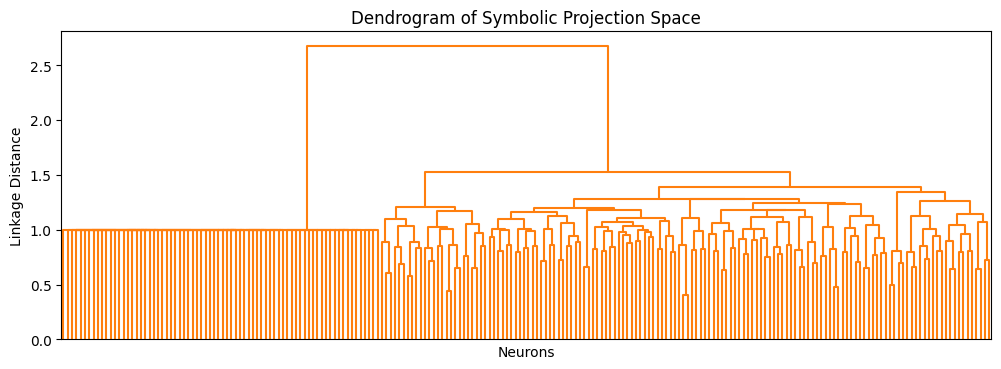

In [55]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# Convert similarity to distance and zero diagonal
func_dist_matrix = 1 - func_sim_matrix
np.fill_diagonal(func_dist_matrix, 0.0)

# Sanity check
assert np.allclose(np.diag(func_dist_matrix), 0), "Diagonal must be zero"

# Convert to condensed form
condensed_func_dist = squareform(func_dist_matrix)

# Hierarchical clustering
Z = linkage(condensed_func_dist, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 4))
dendrogram(Z, labels=shared_neurons, no_labels=True, color_threshold=5)
plt.title("Dendrogram of Symbolic Projection Space")
plt.xlabel("Neurons")
plt.ylabel("Linkage Distance")
plt.show()

# Optional: Flat cluster assignment
cluster_labels = fcluster(Z, t=5, criterion='distance')


In [56]:
# Known circuit neurons (expandable)
locomotion_neurons = {'AVBL', 'AVBR', 'PVCL', 'PVCR', 'DB1', 'DB2', 'VB1', 'VB2'}
egg_laying_neurons = {'HSNL', 'HSNR', 'VC1', 'VC2', 'VC3'}

neuron_tags = {}
for n in shared_neurons:
    if n in locomotion_neurons:
        neuron_tags[n] = 'locomotion'
    elif n in egg_laying_neurons:
        neuron_tags[n] = 'egg-laying'
    else:
        neuron_tags[n] = 'other'


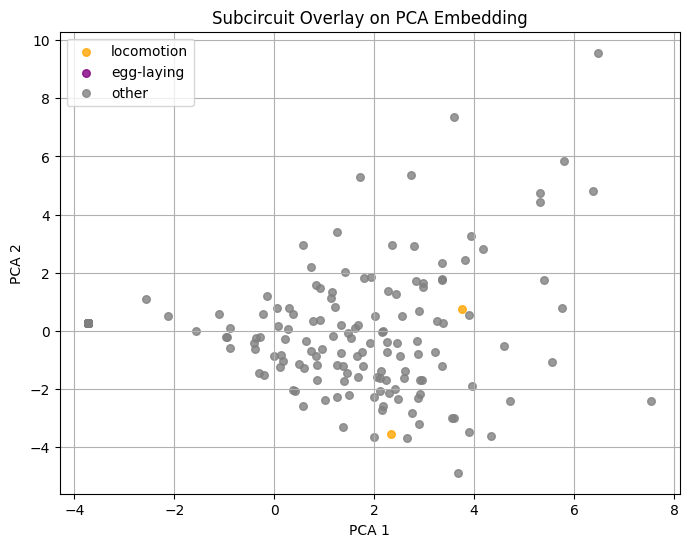

In [57]:
# Color palette
subcircuit_colors = {"locomotion": "orange", "egg-laying": "purple", "other": "gray"}

plt.figure(figsize=(8, 6))
for label, color in subcircuit_colors.items():
    mask = [neuron_tags[n] == label for n in shared_neurons]
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, s=30, alpha=0.8)

plt.title("Subcircuit Overlay on PCA Embedding")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()


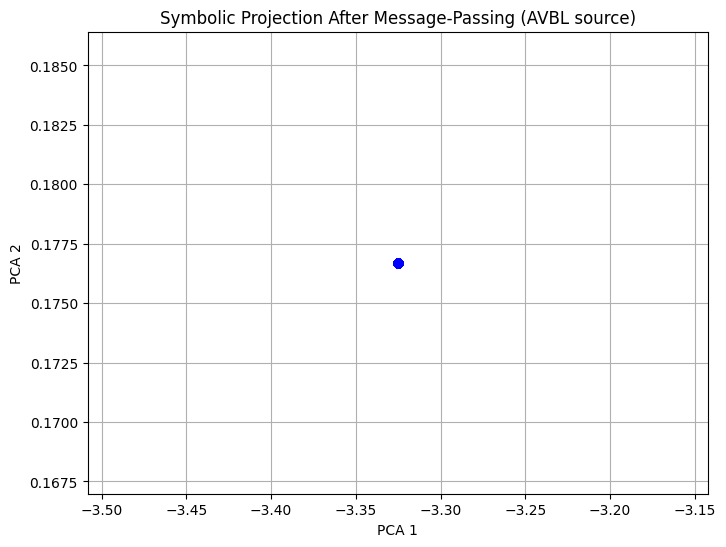

In [58]:
def simulate_symbolic_trajectory(start_neuron, steps=5, decay=0.8):
    state = {n: np.zeros_like(projection_vectors[n]) for n in shared_neurons}
    state[start_neuron] = projection_vectors[start_neuron].copy()

    for t in range(steps):
        new_state = {}
        for neuron in shared_neurons:
            neighbors = input_map.get(neuron, set())
            acc = np.zeros_like(state[neuron])
            for nbr in neighbors:
                if nbr in state:
                    acc += decay * state[nbr]
            new_state[neuron] = acc
        state = new_state

    return state

# Run symbolic diffusion from a motor neuron
trajectory = simulate_symbolic_trajectory("AVBL")

# Visualize endpoint in PCA space
final_vectors = np.array([trajectory[n] for n in shared_neurons])
final_vectors_std = scaler.transform(final_vectors)
final_pca = pca.transform(final_vectors_std)

plt.figure(figsize=(8, 6))
plt.scatter(final_pca[:, 0], final_pca[:, 1], alpha=0.8, c='blue')
plt.title("Symbolic Projection After Message-Passing (AVBL source)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA

# Setup reproducibility
np.random.seed(42)

# Simulated neuron names
neurons = [f"N{i}" for i in range(100)]

# Generate synthetic projection vectors
projection_vectors = {n: np.random.randn(128) for n in neurons}

# Relabel numeric graph to neuron-labeled graph
G_numeric = nx.gnp_random_graph(100, 0.05, directed=True)
G = nx.relabel_nodes(G_numeric, {i: n for i, n in enumerate(neurons)})

# Assign random weights
for u, v in G.edges:
    G[u][v]['weight'] = np.random.rand()

# Symbolic projection matrix
proj_matrix = np.stack([projection_vectors[n] for n in neurons])
neuron_index = {n: i for i, n in enumerate(neurons)}


In [60]:
def symbolic_trajectory(G, proj_matrix, source, neuron_index, hops=5, alpha=0.5):
    if source not in neuron_index:
        raise ValueError(f"Source neuron {source} not found.")
    current = proj_matrix[neuron_index[source]]
    history = [current.copy()]
    
    for _ in range(hops):
        neighbors = list(G.successors(source))
        if not neighbors:
            break
        # Average the neighbors' projection vectors
        aggregate = np.mean([proj_matrix[neuron_index[n]] for n in neighbors if n in neuron_index], axis=0)
        current = alpha * current + (1 - alpha) * aggregate
        history.append(current.copy())
        # Choose next step for symbolic trajectory (random walk)
        source = np.random.choice(neighbors)
    return np.array(history)


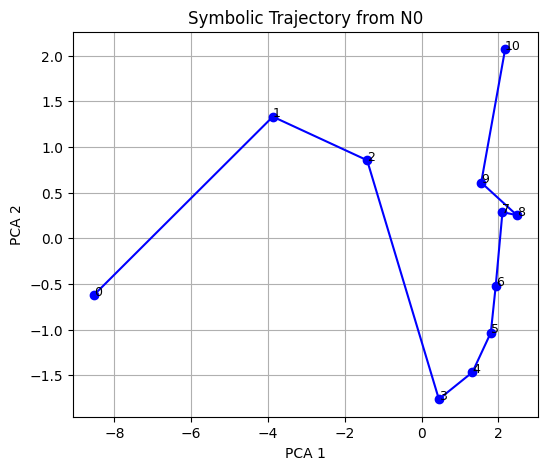

In [61]:
# Pick a locomotion-related neuron if available, fallback to any
source_neuron = "N0"
trajectory = symbolic_trajectory(G, proj_matrix, source_neuron, neuron_index, hops=10, alpha=0.6)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
trajectory_2d = pca.fit_transform(trajectory)

# Plot symbolic trajectory in 2D
plt.figure(figsize=(6, 5))
plt.plot(trajectory_2d[:, 0], trajectory_2d[:, 1], '-o', color='blue')
for i, (x, y) in enumerate(trajectory_2d):
    plt.text(x, y, f"{i}", fontsize=9)
plt.title(f"Symbolic Trajectory from {source_neuron}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


In [62]:
def run_message_passing(G, proj_matrix, neuron_index, sources, steps=5, alpha=0.5):
    # Initialize state matrix (N x D)
    neuron_list = list(neuron_index.keys())
    state = {n: proj_matrix[neuron_index[n]].copy() for n in neuron_list}

    # Track full history
    history = [state.copy()]

    for step in range(steps):
        new_state = {}
        for n in neuron_list:
            neighbors = list(G.predecessors(n))
            if neighbors:
                incoming = np.mean([state[nb] for nb in neighbors if nb in state], axis=0)
                new_state[n] = alpha * state[n] + (1 - alpha) * incoming
            else:
                new_state[n] = state[n]  # no update if no input
        state = new_state
        history.append(state.copy())

    return history  # list of dicts: [{neuron: vec}, ...]


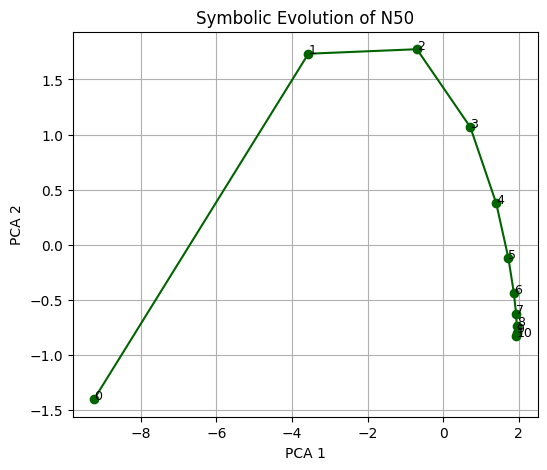

In [64]:
# Run from source neurons (e.g., ["N0", "N1", "N2"])
sources = ["N0", "N1", "N2"]
history = run_message_passing(G, proj_matrix, neuron_index, sources, steps=10)

# Choose a neuron to visualize its state over time
target = "N50"
traj = np.stack([step[target] for step in history])

# PCA projection
pca = PCA(n_components=2)
traj_2d = pca.fit_transform(traj)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(traj_2d[:, 0], traj_2d[:, 1], '-o', color='darkgreen')
for i, (x, y) in enumerate(traj_2d):
    plt.text(x, y, f"{i}", fontsize=9)
plt.title(f"Symbolic Evolution of {target}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


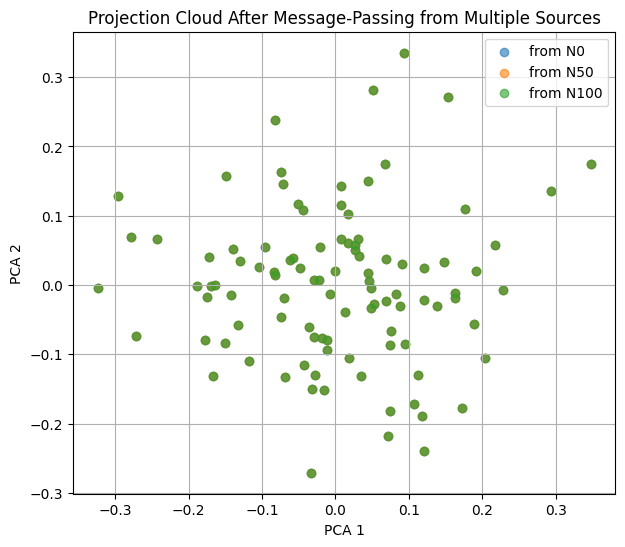

In [65]:
from sklearn.decomposition import PCA

# Choose a few source neurons
sources = ["N0", "N50", "N100"]
all_histories = {}

for src in sources:
    all_histories[src] = run_message_passing(G, proj_matrix, neuron_index, [src], steps=10)[-1]  # last step

# Stack results
final_vectors = []
colors = []
labels = []

for src, state in all_histories.items():
    for n, v in state.items():
        final_vectors.append(v)
        colors.append(src)
        labels.append(n)

# PCA for visualization
final_vectors = np.array(final_vectors)
pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(final_vectors)

# Plot cloud
plt.figure(figsize=(7, 6))
for src in sources:
    idxs = [i for i, c in enumerate(colors) if c == src]
    plt.scatter(vecs_2d[idxs, 0], vecs_2d[idxs, 1], label=f"from {src}", alpha=0.6)

plt.title("Projection Cloud After Message-Passing from Multiple Sources")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()


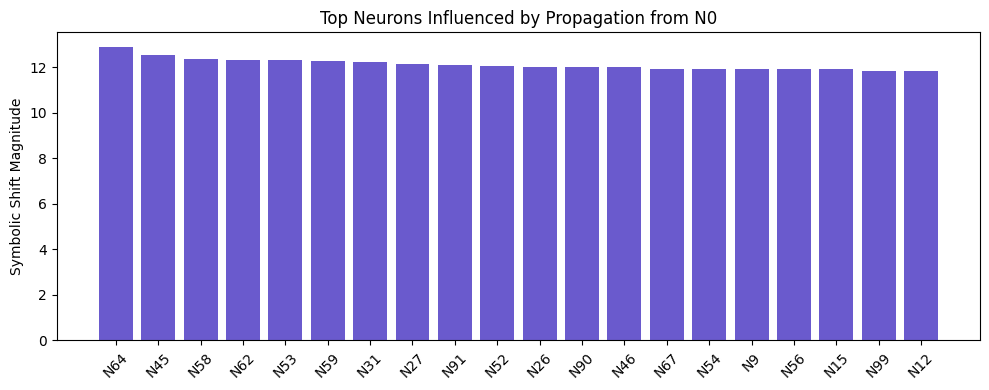

In [66]:
# Measure L2 shift in symbolic representation from t=0 → t=T
def get_propagation_magnitude(G, proj_matrix, neuron_index, source, steps=10):
    hist = run_message_passing(G, proj_matrix, neuron_index, [source], steps)
    base = hist[0]
    final = hist[-1]
    
    shifts = {}
    for n in base:
        shift = np.linalg.norm(final[n] - base[n])
        shifts[n] = shift
    return shifts

# Example: source = "N0"
source = "N0"
shifts = get_propagation_magnitude(G, proj_matrix, neuron_index, source)

# Normalize and sort
sorted_shifts = sorted(shifts.items(), key=lambda x: -x[1])
top_shifted = sorted_shifts[:20]

# Plot bar chart
labels = [k for k, _ in top_shifted]
values = [v for _, v in top_shifted]

plt.figure(figsize=(10, 4))
plt.bar(labels, values, color='slateblue')
plt.title(f"Top Neurons Influenced by Propagation from {source}")
plt.ylabel("Symbolic Shift Magnitude")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [70]:
import pandas as pd

# Load both lineage datasets (Part 1 and Part 2)
df1 = pd.read_excel("NeuronLineage_Part1.xls")
df2 = pd.read_excel("NeuronLineage_Part2.xls")

# Confirm column names
print(f"Part 1 columns: {df1.columns.tolist()}")
print(f"Part 2 columns: {df2.columns.tolist()}")


Part 1 columns: ['Neuron 1', 'Neuron 2', 'Relatedness']
Part 2 columns: ['Neuron 1', 'Neuron 2', 'Relatedness']


In [71]:
# Clean up and standardize names
lineage_df1 = df1.rename(columns={"Neuron 1": "Neuron 1", "Neuron 2": "Neuron 2", "Relatedness": "Relatedness"})
lineage_df2 = df2.rename(columns={"Neuron 1": "Neuron 1", "Neuron 2": "Neuron 2", "Relatedness": "Relatedness"})

# Merge and clean
lineage_df_full = pd.concat([lineage_df1, lineage_df2], ignore_index=True)
lineage_df_full.dropna(subset=["Neuron 1", "Neuron 2", "Relatedness"], inplace=True)

# Standardize case
lineage_df_full["Neuron 1"] = lineage_df_full["Neuron 1"].str.strip().str.upper()
lineage_df_full["Neuron 2"] = lineage_df_full["Neuron 2"].str.strip().str.upper()


In [72]:
import numpy as np

# Get all unique neurons
all_neurons = sorted(set(lineage_df_full["Neuron 1"]) | set(lineage_df_full["Neuron 2"]))

# Initialize matrix with infinity for non-connected pairs
lineage_matrix = pd.DataFrame(np.inf, index=all_neurons, columns=all_neurons, dtype=float)

# Fill with known distances
for _, row in lineage_df_full.iterrows():
    n1, n2, d = row["Neuron 1"], row["Neuron 2"], row["Relatedness"]
    lineage_matrix.at[n1, n2] = d
    lineage_matrix.at[n2, n1] = d

# Diagonal should be 0 (same neuron)
np.fill_diagonal(lineage_matrix.values, 0.0)

print(f"✔️ lineage_matrix shape: {lineage_matrix.shape}")
print(f"🧠 Sample neurons: {all_neurons[:5]}")


✔️ lineage_matrix shape: (279, 279)
🧠 Sample neurons: ['ADAL', 'ADAR', 'ADEL', 'ADER', 'ADFL']


In [78]:
print(list(projection_vectors.keys())[:10])


['N0', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9']


In [79]:
# %%
# Use synthetic source neurons (consistent with projection_vectors)
sources = {
    'N0': 'N0',
    'N50': 'N50',
    'N99': 'N99'
}


# Data Prep

In [83]:
import os
import mimetypes

def explore_directory(root_dir="."):
    print(f"📂 Exploring directory: {os.path.abspath(root_dir)}\n")
    for root, dirs, files in os.walk(root_dir):
        for name in files:
            full_path = os.path.join(root, name)
            mime_type, _ = mimetypes.guess_type(full_path)
            file_type = mime_type if mime_type else "Unknown"
            print(f"[FILE] {full_path} — Type: {file_type}")
        for name in dirs:
            full_path = os.path.join(root, name)
            print(f"[DIR]  {full_path}/")

# Run on current directory (or replace "." with a specific path)
if __name__ == "__main__":
    explore_directory(".")


📂 Exploring directory: /home/rohit/Desktop/Projects/C-Elegans

[FILE] ./c_elegans_connectome_simplified.graphml — Type: Unknown
[FILE] ./connectome.pdf — Type: application/pdf
[FILE] ./celegans.ipynb — Type: Unknown
[FILE] ./NeuronLineage_Part2.xls — Type: application/vnd.ms-excel
[FILE] ./c_elegans_connectome.graphml — Type: Unknown
[FILE] ./celegans.pdf — Type: application/pdf
[FILE] ./ASI.ipynb — Type: Unknown
[FILE] ./NeuronLineage_Part1.xls — Type: application/vnd.ms-excel
[FILE] ./ASI.pdf — Type: application/pdf
[FILE] ./connectome.ipynb — Type: Unknown
[DIR]  ./c302/
[DIR]  ./celegans_connectome_data/
[DIR]  ./CElegansNeuroML/
[DIR]  ./celegans_neural_data/
[FILE] ./c302/_osb.yml — Type: Unknown
[FILE] ./c302/.openworm.yml — Type: Unknown
[FILE] ./c302/cells.md — Type: text/markdown
[FILE] ./c302/.gitignore — Type: Unknown
[FILE] ./c302/OpenWormOverview.md — Type: text/markdown
[FILE] ./c302/README.md — Type: text/markdown
[DIR]  ./c302/examples/
[DIR]  ./c302/.github/
[DIR]  ./

In [86]:
import os
import pandas as pd

# Get the absolute path to the current notebook directory
root_dir = os.getcwd()

# Known file type mapping (extend this as needed)
file_type_map = {
    ".nml": "morphology",
    ".csv": "tabular",
    ".npz": "numpy",
    ".json": "json",
    ".h5": "hdf5",
    ".txt": "text",
    ".npy": "numpy",
    ".xml": "xml",
}

# List to store metadata
data = []

# Recursively walk through the directory
for dirpath, _, filenames in os.walk(root_dir):
    for fname in filenames:
        full_path = os.path.join(dirpath, fname)
        name, ext = os.path.splitext(fname)
        ext = ext.lower()
        modality = file_type_map.get(ext, "other")
        neuron = name.upper() if len(name) <= 6 and name.isalnum() else "unknown"

        data.append({
            "neuron": neuron,
            "filename": fname,
            "full_path": full_path,
            "extension": ext,
            "modality": modality,
            "directory": dirpath,
        })

# Convert to DataFrame
file_index_df = pd.DataFrame(data)

# Save to CSV
file_index_df.to_csv("file_index_master.csv", index=False)

# Preview the top rows
file_index_df.head()


,neuron,filename,full_path,extension,modality,directory
0,unknown,c_elegans_connectome_simplified.graphml,/home/rohit/Desktop/Projects/C-Elegans/c_elega...,.graphml,other,/home/rohit/Desktop/Projects/C-Elegans
1,unknown,connectome.pdf,/home/rohit/Desktop/Projects/C-Elegans/connect...,.pdf,other,/home/rohit/Desktop/Projects/C-Elegans
2,unknown,celegans.ipynb,/home/rohit/Desktop/Projects/C-Elegans/celegan...,.ipynb,other,/home/rohit/Desktop/Projects/C-Elegans
3,unknown,NeuronLineage_Part2.xls,/home/rohit/Desktop/Projects/C-Elegans/NeuronL...,.xls,other,/home/rohit/Desktop/Projects/C-Elegans
4,unknown,c_elegans_connectome.graphml,/home/rohit/Desktop/Projects/C-Elegans/c_elega...,.graphml,other,/home/rohit/Desktop/Projects/C-Elegans


In [87]:
import pandas as pd

# Load the master file index
file_index_df = pd.read_csv("file_index_master.csv")

# Count by extension
ext_counts = file_index_df['extension'].value_counts().reset_index()
ext_counts.columns = ['extension', 'count']

# Count by modality
modality_counts = file_index_df['modality'].value_counts().reset_index()
modality_counts.columns = ['modality', 'count']

# Display
print("📦 File Type Distribution by Extension:")
print(ext_counts.to_string(index=False))

print("\n🔬 File Modality Distribution:")
print(modality_counts.to_string(index=False))


📦 File Type Distribution by Extension:
extension  count
     .nml   1664
     .xml   1125
      .py     96
  .sample     52
     .xsl     50
     .omt     33
     .png     17
      .md     13
     .mep     12
    .xlsx     12
      .pt     11
     .csv     10
    .json      9
     .yml      7
     .xls      5
    .pack      4
     .idx      4
   .ipynb      3
     .pdf      3
 .graphml      2
     .txt      2
      .sh      2
     .ncx      1
    .html      1
     .tsv      1
 .parquet      1

🔬 File Modality Distribution:
  modality  count
morphology   1664
       xml   1125
     other    408
   tabular     10
      json      9
      text      2


In [90]:
import pandas as pd
from pathlib import Path

# Define allowed spreadsheet extensions
spreadsheet_exts = {'.csv', '.tsv', '.xls', '.xlsx'}

# Create a dictionary to hold DataFrames
spreadsheet_data = {}

# Base directory (same as notebook)
base_dir = Path().resolve()

# Recursively find all relevant files
spreadsheet_files = [f for f in base_dir.rglob("*") if f.suffix in spreadsheet_exts]

print(f"📊 Found {len(spreadsheet_files)} spreadsheet files\n")

# Load and preview each file
for fpath in spreadsheet_files:
    print(f"📄 {fpath.relative_to(base_dir)}")
    try:
        if fpath.suffix == '.csv':
            df = pd.read_csv(fpath)
        elif fpath.suffix == '.tsv':
            df = pd.read_csv(fpath, sep='\t')
        elif fpath.suffix in ['.xls', '.xlsx']:
            df = pd.read_excel(fpath)
        else:
            print("⚠️ Unsupported format:", fpath.suffix)
            continue
        
        # Store and preview
        spreadsheet_data[fpath.name] = df
        print(f"✅ Loaded: shape = {df.shape}")
        print("🔍 Columns:", list(df.columns))
        print(df.head(2))
        print("—" * 80)
    
    except Exception as e:
        print(f"❌ Failed to load {fpath.name}: {e}")
        print("—" * 80)


📊 Found 29 spreadsheet files

📄 NeuronLineage_Part2.xls
✅ Loaded: shape = (38781, 3)
🔍 Columns: ['Neuron 1', 'Neuron 2', 'Relatedness']
  Neuron 1 Neuron 2  Relatedness
0     ADAL    SMDDR           16
1     ADAR    SMDDR           14
————————————————————————————————————————————————————————————————————————————————
📄 NeuronLineage_Part1.xls
✅ Loaded: shape = (38781, 3)
🔍 Columns: ['Neuron 1', 'Neuron 2', 'Relatedness']
  Neuron 1 Neuron 2  Relatedness
0     BAGR     BAGL           15
1    CEPVL     BAGL           18
————————————————————————————————————————————————————————————————————————————————
📄 file_index_master.csv
✅ Loaded: shape = (3218, 6)
🔍 Columns: ['neuron', 'filename', 'full_path', 'extension', 'modality', 'directory']
    neuron                                 filename  \
0  unknown  c_elegans_connectome_simplified.graphml   
1  unknown                           connectome.pdf   

                                           full_path extension modality  \
0  /home/rohit/Deskt

In [107]:
import pandas as pd

# Load the two lineage files
lineage1 = pd.read_excel('NeuronLineage_Part1.xls')
lineage2 = pd.read_excel('NeuronLineage_Part2.xls')

# Combine them
combined_lineage = pd.concat([lineage1, lineage2], ignore_index=True)

# Standardize column names (just in case)
combined_lineage.columns = ['Neuron1', 'Neuron2', 'Relatedness']

# Remove rows with missing values
combined_lineage.dropna(inplace=True)

# Normalize pairs so that Neuron1 < Neuron2 (alphabetically), to treat (A,B) same as (B,A)
combined_lineage[['NeuronA', 'NeuronB']] = combined_lineage[['Neuron1', 'Neuron2']].apply(sorted, axis=1, result_type='expand')

# Group by unordered neuron pairs and average relatedness
cleaned_lineage = (
    combined_lineage
    .groupby(['NeuronA', 'NeuronB'])['Relatedness']
    .mean()
    .reset_index()
)

# Preview
print(cleaned_lineage.head())
cleaned_lineage.to_csv('merged_lineage_table.csv', index=False)

  NeuronA NeuronB  Relatedness
0    ADAL    ADAR         17.0
1    ADAL    ADEL          1.0
2    ADAL    ADER         17.0
3    ADAL    ADFL         18.0
4    ADAL    ADFR         16.0


In [108]:
# 📊 Sanity check + Descriptive statistics for merged lineage dataset

# Load merged file if not already loaded
lineage_df = pd.read_csv("merged_lineage_table.csv")

print("✅ Loaded merged lineage file")
print(f"Shape: {lineage_df.shape}")
print("\n📌 Column names:", lineage_df.columns.tolist())

# Check for missing values
print("\n🔍 Null values per column:")
print(lineage_df.isnull().sum())

# Check for non-unique neuron pairs
duplicate_rows = lineage_df.duplicated(subset=["NeuronA", "NeuronB"])
print(f"\n⚠️ Duplicate NeuronA–NeuronB pairs: {duplicate_rows.sum()}")

# Unique neurons involved
unique_neurons = pd.unique(lineage_df[['NeuronA', 'NeuronB']].values.ravel())
print(f"\n🧠 Total unique neurons: {len(unique_neurons)}")

# Descriptive stats on Relatedness
print("\n📈 Relatedness statistics:")
print(lineage_df["Relatedness"].describe())

# Value counts for rounded relatedness (helps spot suspicious peaks)
print("\n🔬 Rounded relatedness frequency:")
print(lineage_df["Relatedness"].round().value_counts().sort_index())


✅ Loaded merged lineage file
Shape: (38781, 3)

📌 Column names: ['NeuronA', 'NeuronB', 'Relatedness']

🔍 Null values per column:
NeuronA        0
NeuronB        0
Relatedness    0
dtype: int64

⚠️ Duplicate NeuronA–NeuronB pairs: 0

🧠 Total unique neurons: 279

📈 Relatedness statistics:
count    38781.000000
mean        16.229984
std          3.225926
min          1.000000
25%         15.000000
50%         17.000000
75%         18.000000
max         25.000000
Name: Relatedness, dtype: float64

🔬 Rounded relatedness frequency:
Relatedness
1.0       86
2.0       46
3.0       86
4.0      126
5.0      142
6.0       82
7.0      319
8.0      218
9.0      605
10.0     521
11.0    1139
12.0     859
13.0    1929
14.0    2091
15.0    4640
16.0    3706
17.0    7706
18.0    6042
19.0    4004
20.0    2884
21.0    1143
22.0     329
23.0      71
24.0       6
25.0       1
Name: count, dtype: int64


In [109]:
import pandas as pd
from pathlib import Path

# Load the master index
file_index = pd.read_csv("file_index_master.csv")

# Define valid spreadsheet extensions
spreadsheet_exts = ['.xls', '.xlsx', '.csv', '.tsv']

# Filter out spreadsheet files
spreadsheet_files = file_index[file_index['extension'].isin(spreadsheet_exts)]

# Helper to try loading a file
def try_load_spreadsheet(path):
    try:
        if path.suffix in ['.xls', '.xlsx']:
            df = pd.read_excel(path)
        elif path.suffix == '.csv':
            df = pd.read_csv(path)
        elif path.suffix == '.tsv':
            df = pd.read_csv(path, sep='\t')
        else:
            return None, "Unsupported extension"
        summary = {
            "filename": str(path),
            "shape": df.shape,
            "columns": df.columns.tolist(),
            "null_counts": df.isnull().sum().to_dict(),
            "head": df.head(2).to_dict(orient='records'),
        }
        return summary, None
    except Exception as e:
        return None, str(e)

# Go through each file and analyze
summaries = []
for i, row in spreadsheet_files.iterrows():
    path = Path(row['full_path'])
    summary, error = try_load_spreadsheet(path)
    if summary:
        summaries.append(summary)
    else:
        summaries.append({
            "filename": str(path),
            "error": error
        })

# Show summaries one by one
for s in summaries:
    print("————————————————————————————————————————————————————————————————————————————————")
    print("📄", s["filename"])
    if "error" in s:
        print("❌ Error:", s["error"])
    else:
        print("✅ Loaded: shape =", s["shape"])
        print("🔍 Columns:", s["columns"])
        print("⚠️ Null values per column:", s["null_counts"])
        print("👀 Head preview:")
        for row in s["head"]:
            print(" ", row)


————————————————————————————————————————————————————————————————————————————————
📄 /home/rohit/Desktop/Projects/C-Elegans/NeuronLineage_Part2.xls
✅ Loaded: shape = (38781, 3)
🔍 Columns: ['Neuron 1', 'Neuron 2', 'Relatedness']
⚠️ Null values per column: {'Neuron 1': 0, 'Neuron 2': 0, 'Relatedness': 0}
👀 Head preview:
  {'Neuron 1': 'ADAL', 'Neuron 2': 'SMDDR', 'Relatedness': 16}
  {'Neuron 1': 'ADAR', 'Neuron 2': 'SMDDR', 'Relatedness': 14}
————————————————————————————————————————————————————————————————————————————————
📄 /home/rohit/Desktop/Projects/C-Elegans/NeuronLineage_Part1.xls
✅ Loaded: shape = (38781, 3)
🔍 Columns: ['Neuron 1', 'Neuron 2', 'Relatedness']
⚠️ Null values per column: {'Neuron 1': 0, 'Neuron 2': 0, 'Relatedness': 0}
👀 Head preview:
  {'Neuron 1': 'BAGR', 'Neuron 2': 'BAGL', 'Relatedness': 15}
  {'Neuron 1': 'CEPVL', 'Neuron 2': 'BAGL', 'Relatedness': 18}
————————————————————————————————————————————————————————————————————————————————
📄 /home/rohit/Desktop/Projects/C

In [110]:
# Categorization rules by keyword matches in filename and column names
def categorize_file(summary):
    if "error" in summary:
        return "⚠️ Error - Skipped"

    cols = [c.lower() for c in summary['columns']]
    fname = summary['filename'].lower()

    if set(cols) >= {'neuron 1', 'neuron 2', 'relatedness'}:
        return "📚 Lineage Table"
    elif set(cols) >= {'source', 'target', 'weight', 'type'} or set(cols) >= {'pre', 'post', 'type', 'synapses'}:
        return "🧠 Edge List"
    elif "adjacency" in fname or summary['shape'][0] == summary['shape'][1]:
        return "🧮 Adjacency Matrix"
    elif "expression" in fname:
        return "🧬 Expression / Molecular"
    elif "synapse" in fname and "matrix" in fname:
        return "🔢 Synapse Count Matrix"
    elif "connectome" in fname and "full" in fname:
        return "📊 Full Connectome"
    elif "file_index_master" in fname:
        return "📂 File Index / Metadata"
    elif "neuro" in fname and "tables" in fname:
        return "📋 Neuron Metadata"
    elif fname.endswith(".tsv"):
        return "📏 Morphological Coordinates"
    else:
        return "❓ Unclassified"

# Group summaries by category
from collections import defaultdict
grouped = defaultdict(list)
for summary in summaries:
    category = categorize_file(summary)
    grouped[category].append(summary)

# Print results per group
for category, files in grouped.items():
    print("\n" + "🔷" * 30)
    print(f"🔹 Category: {category} — {len(files)} files")
    print("🔷" * 30)
    for f in files:
        print("📄", Path(f['filename']).name)
        if "shape" in f:
            print("   Shape:", f['shape'])
            print("   Columns:", f['columns'][:6])
        if "error" in f:
            print("   ❌ Error:", f['error'])



🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷
🔹 Category: 📚 Lineage Table — 2 files
🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷
📄 NeuronLineage_Part2.xls
   Shape: (38781, 3)
   Columns: ['Neuron 1', 'Neuron 2', 'Relatedness']
📄 NeuronLineage_Part1.xls
   Shape: (38781, 3)
   Columns: ['Neuron 1', 'Neuron 2', 'Relatedness']

🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷
🔹 Category: ❓ Unclassified — 9 files
🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷🔷
📄 NeuronConnectFormatted.xlsx
   Shape: (6417, 4)
   Columns: ['Neuron 1', 'Neuron 2', 'Type', 'Nbr']
📄 aconnectome_white_1986_A.csv
   Shape: (1899, 1)
   Columns: ['pre post type synapses']
📄 NeuronConnectFormatted.xlsx
   Shape: (6417, 4)
   Columns: ['Neuron 1', 'Neuron 2', 'Type', 'Nbr']
📄 aconnectome_white_1986_L4.csv
   Shape: (1769, 1)
   Columns: ['pre\tpost\ttype\tsynapses']
📄 NeuronConnectFormatted.xls
   Shape: (6417, 4)
   Columns: ['Neuron 1', 'Neuron 2', 'Type', 'Nbr']
📄 aconnectome_white_1986_whole.csv
   Shape: (2961, 1)
   Columns: ['pre\tpost\ttype\tsynapses']
📄 synapse_count

In [111]:
import os
import pandas as pd

# Keywords for identifying edge list files
target_files = {
    "herm_full_edgelist.csv",
    "herm_full_edgelist_MODIFIED.csv",
    "witvliet_2020_1.xlsx",
    "witvliet_2020_2.xlsx",
    "witvliet_2020_3.xlsx",
    "witvliet_2020_4.xlsx",
    "witvliet_2020_5.xlsx",
    "witvliet_2020_6.xlsx",
    "witvliet_2020_7.xlsx",
    "witvliet_2020_8.xlsx",
}

# Root directory (same as notebook)
root_dir = os.getcwd()

# List to collect loaded DataFrames
merged_edges = []

# Recursively walk through the directory
for subdir, dirs, files in os.walk(root_dir):
    for filename in files:
        if filename in target_files:
            filepath = os.path.join(subdir, filename)
            print(f"📂 Loading: {filepath}")

            try:
                if "herm" in filename:
                    df = pd.read_csv(filepath)
                    df = df.rename(columns={
                        "Source": "Source", "Target": "Target", 
                        "Type": "Type", "Weight": "SynapseCount"
                    })
                else:
                    df = pd.read_excel(filepath)
                    df = df.rename(columns={
                        "pre": "Source", "post": "Target", 
                        "type": "Type", "synapses": "SynapseCount"
                    })

                df["SourceFile"] = filename
                df = df[["Source", "Target", "Type", "SynapseCount", "SourceFile"]]
                df.dropna(subset=["Source", "Target", "Type"], inplace=True)
                df["Type"] = df["Type"].str.strip().str.lower()

                merged_edges.append(df)

            except Exception as e:
                print(f"⚠️ Failed to load {filename}: {e}")

# Combine into one DataFrame
if merged_edges:
    edges_df = pd.concat(merged_edges, ignore_index=True)
    print("✅ All edge files merged")
    print("🔢 Shape:", edges_df.shape)
    print("🔍 Type distribution:\n", edges_df["Type"].value_counts())
    print("🧠 Example rows:")
    print(edges_df.head())
else:
    print("❌ No edge files were found.")


📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/witvliet_2020_2.xlsx
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/witvliet_2020_6.xlsx
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/herm_full_edgelist_MODIFIED.csv
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/witvliet_2020_5.xlsx
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/witvliet_2020_4.xlsx
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/herm_full_edgelist.csv
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/witvliet_2020_1.xlsx
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/witvliet_2020_3.xlsx
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/witvliet_2020_8.xlsx
📂 Loading: /home/rohit/Desktop/Projects/C-Elegans/c302/c302/data/witvliet_2020_7.xlsx
✅ All edge files merged
🔢 Shape: (27727, 5)
🔍 Type distribution:
 Type
chemical      20714
electrical     7013
Name: count, dty

In [112]:
# If you accidentally stored individual DataFrames in a list called `merged_edges`, finalize the merge:
merged_edges = pd.concat(merged_edges, ignore_index=True)


In [113]:
print("📊 Edge DataFrame Overview")
print("=" * 50)

# Shape and columns
print(f"🔢 Shape: {merged_edges.shape}")
print(f"📌 Columns: {merged_edges.columns.tolist()}\n")

# Null checks
print("🧪 Null Values:")
print(merged_edges.isnull().sum(), "\n")

# Type checks for SynapseCount
print("🔍 SynapseCount dtype:", merged_edges['SynapseCount'].dtype)
print("📈 SynapseCount Summary:")
print(merged_edges['SynapseCount'].describe(), "\n")

# Unique types and source files
print("🔌 Synapse Types:", merged_edges['Type'].unique())
print("📁 Unique Source Files:", merged_edges['SourceFile'].nunique(), "\n")

# Self-loops and duplicate edges
self_loops = merged_edges[merged_edges['Source'] == merged_edges['Target']]
duplicate_edges = merged_edges.duplicated(subset=['Source', 'Target', 'Type'], keep=False)

print(f"🔁 Self-loops: {len(self_loops)}")
print(f"📎 Duplicate Edges (Source, Target, Type): {duplicate_edges.sum()}\n")

# Unique neurons
neurons = pd.unique(merged_edges[['Source', 'Target']].values.ravel())
print(f"🧠 Unique neurons involved: {len(neurons)}")

# Sample rows
print("\n🎯 Sample entries:")
display(merged_edges.sample(5))


📊 Edge DataFrame Overview
🔢 Shape: (27727, 5)
📌 Columns: ['Source', 'Target', 'Type', 'SynapseCount', 'SourceFile']

🧪 Null Values:
Source          0
Target          0
Type            0
SynapseCount    0
SourceFile      0
dtype: int64 

🔍 SynapseCount dtype: int64
📈 SynapseCount Summary:
count    27727.000000
mean         4.100444
std          6.047872
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        142.000000
Name: SynapseCount, dtype: float64 

🔌 Synapse Types: ['electrical' 'chemical']
📁 Unique Source Files: 10 

🔁 Self-loops: 42
📎 Duplicate Edges (Source, Target, Type): 25967

🧠 Unique neurons involved: 1533

🎯 Sample entries:


,Source,Target,Type,SynapseCount,SourceFile
18847,RIAL,SMDVL,electrical,4,herm_full_edgelist.csv
23498,AVHR,SMBDL,chemical,2,witvliet_2020_8.xlsx
27603,URAVR,RMER,chemical,4,witvliet_2020_7.xlsx
14827,AIBL,SIBDR,chemical,3,herm_full_edgelist.csv
24531,RIH,OLQVL,chemical,4,witvliet_2020_8.xlsx


In [114]:
merged_edges.to_csv('merged_edges.csv', index=False)

In [115]:
import pandas as pd

# Load cleaned edge and lineage datasets
edges_df = pd.read_csv("merged_edges.csv")
lineage_df = pd.read_csv("merged_lineage_table.csv")

print("✅ Files loaded")
print(f"📦 Edges shape: {edges_df.shape}")
print(f"📦 Lineage shape: {lineage_df.shape}")


✅ Files loaded
📦 Edges shape: (27727, 5)
📦 Lineage shape: (38781, 3)


In [116]:
print("🔍 Column Check – Edges")
print(edges_df.columns)
print("\n🔍 Column Check – Lineage")
print(lineage_df.columns)

print("\n🧪 Null Values – Edges")
print(edges_df.isnull().sum())

print("\n🧪 Null Values – Lineage")
print(lineage_df.isnull().sum())

print("\n🔎 Data Types – SynapseCount and Relatedness")
print("SynapseCount dtype:", edges_df['SynapseCount'].dtype)
print("Relatedness dtype:", lineage_df['Relatedness'].dtype)


🔍 Column Check – Edges
Index(['Source', 'Target', 'Type', 'SynapseCount', 'SourceFile'], dtype='object')

🔍 Column Check – Lineage
Index(['NeuronA', 'NeuronB', 'Relatedness'], dtype='object')

🧪 Null Values – Edges
Source          0
Target          0
Type            0
SynapseCount    0
SourceFile      0
dtype: int64

🧪 Null Values – Lineage
NeuronA        0
NeuronB        0
Relatedness    0
dtype: int64

🔎 Data Types – SynapseCount and Relatedness
SynapseCount dtype: int64
Relatedness dtype: float64


In [117]:
# Check self-loops
edge_self_loops = edges_df[edges_df["Source"] == edges_df["Target"]]
print(f"🔁 Self-loops in edges: {len(edge_self_loops)}")

# Check duplicates
duplicate_edges = edges_df.duplicated(subset=["Source", "Target", "Type"])
print(f"📎 Duplicate edge entries: {duplicate_edges.sum()}")

duplicate_lineage = lineage_df.duplicated(subset=["NeuronA", "NeuronB"])
print(f"📎 Duplicate lineage pairs: {duplicate_lineage.sum()}")


🔁 Self-loops in edges: 42
📎 Duplicate edge entries: 16035
📎 Duplicate lineage pairs: 0


In [118]:
# All neurons from edge list
edge_neurons = pd.unique(edges_df[["Source", "Target"]].values.ravel())

# All neurons from lineage
lineage_neurons = pd.unique(lineage_df[["NeuronA", "NeuronB"]].values.ravel())

# Union, intersection, orphan sets
edge_set = set(edge_neurons)
lineage_set = set(lineage_neurons)

only_in_edges = edge_set - lineage_set
only_in_lineage = lineage_set - edge_set
common = edge_set & lineage_set

print(f"🧠 Unique neurons in edges: {len(edge_set)}")
print(f"🧬 Unique neurons in lineage: {len(lineage_set)}")
print(f"🔁 Overlapping neurons: {len(common)}")
print(f"⚠️ Orphan neurons (edges only): {len(only_in_edges)}")
print(f"⚠️ Orphan neurons (lineage only): {len(only_in_lineage)}")


🧠 Unique neurons in edges: 1533
🧬 Unique neurons in lineage: 279
🔁 Overlapping neurons: 180
⚠️ Orphan neurons (edges only): 1353
⚠️ Orphan neurons (lineage only): 99


In [119]:
# Aggregate edge counts
agg_edges = edges_df.groupby(["Source", "Target", "Type"]).agg({
    "SynapseCount": "sum"
}).reset_index()

print(f"📊 Aggregated edges: {agg_edges.shape[0]}")
print("🎯 SynapseCount summary:")
print(agg_edges["SynapseCount"].describe())


📊 Aggregated edges: 11692
🎯 SynapseCount summary:
count    11692.000000
mean         9.723999
std         14.787880
min          1.000000
25%          2.000000
50%          4.000000
75%         10.000000
max        284.000000
Name: SynapseCount, dtype: float64


In [120]:
# Optional: convert to square matrix for heatmap or analysis
pivot = lineage_df.pivot(index="NeuronA", columns="NeuronB", values="Relatedness")
print(f"🧩 Relatedness matrix shape: {pivot.shape}")
print("📌 Sample:")
print(pivot.iloc[:5, :5])


🧩 Relatedness matrix shape: (278, 278)
📌 Sample:
NeuronB  ADAR  ADEL  ADER  ADFL  ADFR
NeuronA                              
ADAL     17.0   1.0  17.0  18.0  16.0
ADAR      NaN  17.0   1.0  18.0  12.0
ADEL      NaN   NaN  17.0  18.0  16.0
ADER      NaN   NaN   NaN  18.0  12.0
ADFL      NaN   NaN   NaN   NaN  17.0


In [121]:
# Clone the lineage DataFrame with swapped columns to ensure symmetry
lineage_flipped = lineage_df.rename(columns={
    "NeuronA": "NeuronB",
    "NeuronB": "NeuronA"
})

# Combine original and flipped
lineage_symmetric = pd.concat([lineage_df, lineage_flipped], ignore_index=True)

# Optional: normalize column names
lineage_symmetric.columns = ["NeuronA", "NeuronB", "Relatedness"]


In [122]:
# First merge with (Source → NeuronA, Target → NeuronB)
edges_with_lineage = pd.merge(
    merged_edges,
    lineage_symmetric,
    left_on=["Source", "Target"],
    right_on=["NeuronA", "NeuronB"],
    how="left"
)

# Try flipped (Target → NeuronA, Source → NeuronB) for unmatched rows
remaining_unmatched = edges_with_lineage[edges_with_lineage["Relatedness"].isnull()]
flipped_merge = pd.merge(
    remaining_unmatched.drop(columns=["Relatedness", "NeuronA", "NeuronB"], errors="ignore"),
    lineage_symmetric,
    left_on=["Target", "Source"],
    right_on=["NeuronA", "NeuronB"],
    how="left"
)

# Combine original with flipped matches
edges_with_lineage.update(flipped_merge)

# Drop the temporary merge keys
edges_with_lineage = edges_with_lineage.drop(columns=["NeuronA", "NeuronB"])


In [123]:
print("🔍 Lineage annotations added")
print(f"🧠 Total edges: {len(edges_with_lineage)}")
print(f"🔗 With Relatedness info: {edges_with_lineage['Relatedness'].notnull().sum()}")
print(f"🚫 Without Relatedness info: {edges_with_lineage['Relatedness'].isnull().sum()}")

# View correlation
display(edges_with_lineage[['SynapseCount', 'Relatedness']].dropna().corr())


🔍 Lineage annotations added
🧠 Total edges: 27727
🔗 With Relatedness info: 11485
🚫 Without Relatedness info: 16242


,SynapseCount,Relatedness
SynapseCount,1.000000,0.013397
Relatedness,0.013397,1.000000


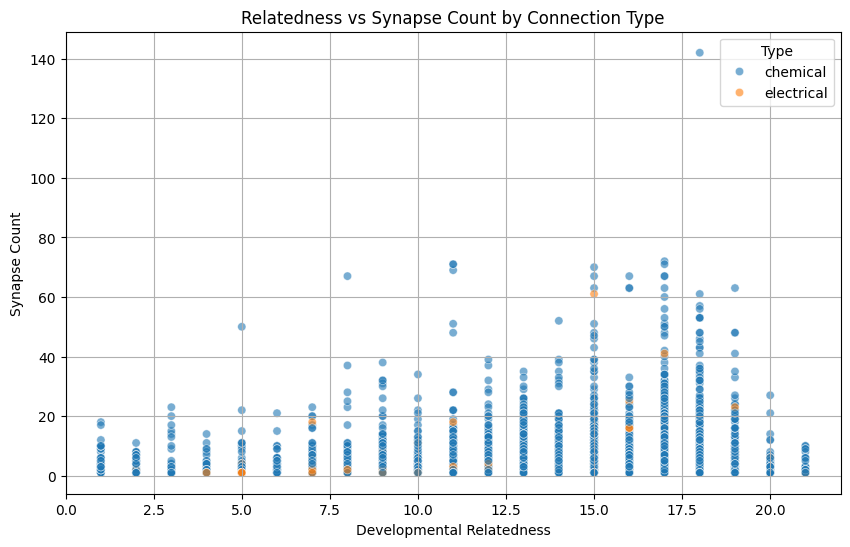

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram: Are strongly connected pairs also developmentally close?
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=edges_with_lineage.dropna(subset=['Relatedness']),
    x='Relatedness', y='SynapseCount',
    hue='Type', alpha=0.6
)
plt.title("Relatedness vs Synapse Count by Connection Type")
plt.xlabel("Developmental Relatedness")
plt.ylabel("Synapse Count")
plt.grid(True)
plt.show()


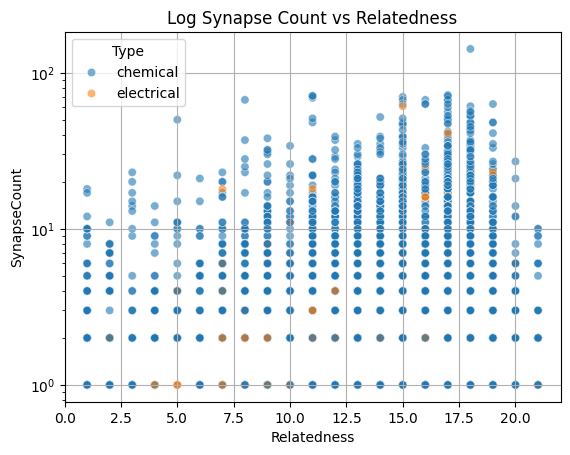

In [125]:
sns.scatterplot(
    data=edges_with_lineage.dropna(subset=['Relatedness']),
    x='Relatedness', y='SynapseCount',
    hue='Type', alpha=0.6
)
plt.yscale('log')
plt.title("Log Synapse Count vs Relatedness")
plt.grid(True)
plt.show()


<Axes: title={'center': 'Avg SynapseCount by Relatedness'}, xlabel='Relatedness'>

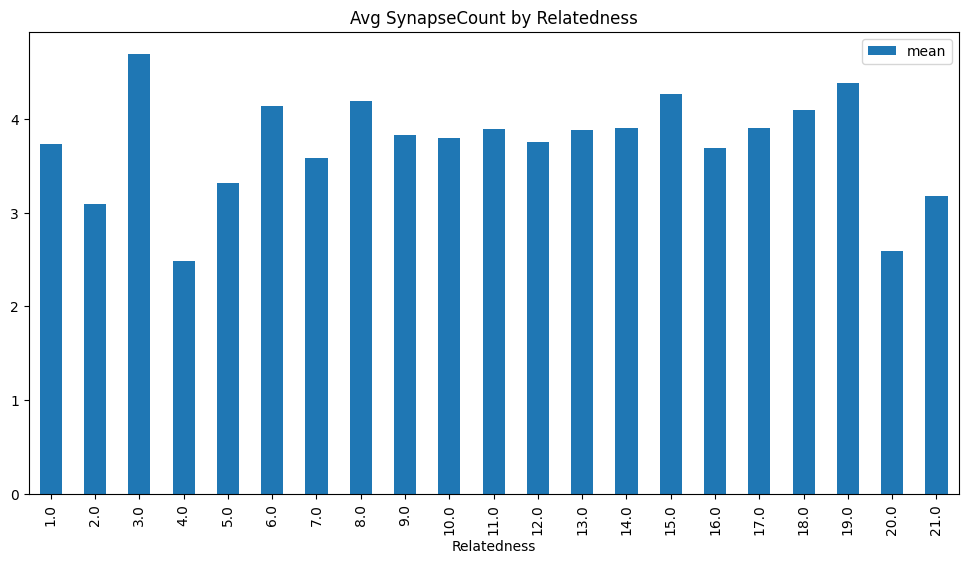

In [126]:
summary = (
    edges_with_lineage
    .dropna(subset=['Relatedness'])
    .groupby('Relatedness')['SynapseCount']
    .agg(['mean', 'count', 'std'])
)

summary.plot(y='mean', kind='bar', figsize=(12,6), title="Avg SynapseCount by Relatedness")


In [127]:
siblings = edges_with_lineage[edges_with_lineage['Relatedness'] <= 3]
print(f"Sibling connections: {len(siblings)}")
display(siblings.sort_values('SynapseCount', ascending=False).head(10))


Sibling connections: 156


,Source,Target,Type,SynapseCount,SourceFile,Relatedness
788,AWAR,AFDR,chemical,23,herm_full_edgelist_MODIFIED.csv,3.0
1461,URXR,RIAR,chemical,20,herm_full_edgelist_MODIFIED.csv,3.0
1406,BAGL,RIAR,chemical,18,herm_full_edgelist_MODIFIED.csv,1.0
10976,RMDDR,dBWML4,chemical,17,herm_full_edgelist.csv,1.0
11325,SIADL,SMDDL,chemical,17,herm_full_edgelist.csv,3.0
11063,RMDVR,vBWML2,chemical,15,herm_full_edgelist.csv,3.0
10637,PVCR,AVBR,chemical,14,herm_full_edgelist.csv,3.0
12209,VA07,VD07,chemical,13,herm_full_edgelist.csv,3.0
26048,AWBL,ADFL,chemical,12,witvliet_2020_7.xlsx,1.0
10682,AVAL,AS09,chemical,11,herm_full_edgelist.csv,2.0


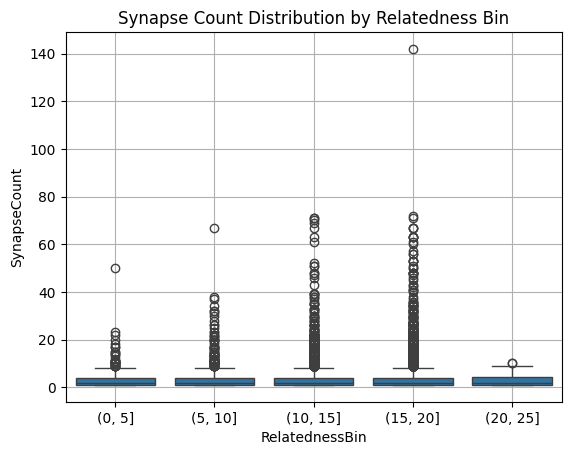

In [128]:
edges_bin = edges_with_lineage.dropna(subset=['Relatedness']).copy()
edges_bin['RelatednessBin'] = pd.cut(edges_bin['Relatedness'], bins=[0, 5, 10, 15, 20, 25])

sns.boxplot(x='RelatednessBin', y='SynapseCount', data=edges_bin)
plt.title("Synapse Count Distribution by Relatedness Bin")
plt.grid(True)
plt.show()


In [130]:
import pandas as pd

# Load the two lineage files
lineage1 = pd.read_excel("NeuronLineage_Part1.xls")
lineage2 = pd.read_excel("NeuronLineage_Part2.xls")

# Standardize column names
lineage1.columns = lineage2.columns = ["NeuronA", "NeuronB", "Relatedness"]

# Combine and remove duplicates
lineage_df = pd.concat([lineage1, lineage2], ignore_index=True).drop_duplicates()


In [131]:
# Add reverse pairs to ensure symmetry
lineage_reversed = lineage_df.rename(columns={"NeuronA": "NeuronB", "NeuronB": "NeuronA"})
lineage_full = pd.concat([lineage_df, lineage_reversed], ignore_index=True).drop_duplicates()


In [132]:
# Merge lineage data onto merged_edges
merged_with_lineage = merged_edges.merge(
    lineage_full, how="left",
    left_on=["Source", "Target"],
    right_on=["NeuronA", "NeuronB"]
)

# Drop temporary columns
merged_with_lineage.drop(columns=["NeuronA", "NeuronB"], inplace=True)


In [133]:
# Try reverse direction for unmatched entries
unmatched = merged_with_lineage[merged_with_lineage['Relatedness'].isna()]

# Merge those with reversed Source/Target
reversed_merge = unmatched.drop(columns=["Relatedness"]).merge(
    lineage_full, how="left",
    left_on=["Target", "Source"],
    right_on=["NeuronA", "NeuronB"]
)

# Drop temp and overwrite unmatched rows
reversed_merge.drop(columns=["NeuronA", "NeuronB"], inplace=True)
merged_with_lineage.update(reversed_merge)


In [ ]:
# Export to CSV
merged_with_lineage.to_csv("merged_edges_with_relatedness.csv", index=False)

# Summary check
print("✅ Exported merged_edges_with_relatedness.csv")
print(f"📊 Total rows: {merged_with_lineage.shape[0]}")
print(f"🧬 With Relatedness: {(~merged_with_lineage['Relatedness'].isna()).sum()}")
print(f"🚫 Without Relatedness: {(merged_with_lineage['Relatedness'].isna()).sum()}")


✅ Exported merged_edges_with_relatedness.csv
📊 Total rows: 27727
🧬 With Relatedness: 11485
🚫 Without Relatedness: 16242


In [135]:
import pandas as pd

# Load the merged file
df = pd.read_csv("merged_edges_with_relatedness.csv")

# Print basic info
print("✅ File loaded")
print(f"📦 Shape: {df.shape}")
print(f"📌 Columns: {df.columns.tolist()}")

# Preview
df.head()


✅ File loaded
📦 Shape: (27727, 6)
📌 Columns: ['Source', 'Target', 'Type', 'SynapseCount', 'SourceFile', 'Relatedness']


,Source,Target,Type,SynapseCount,SourceFile,Relatedness
0,AINL,CEPshVR,chemical,1,witvliet_2020_2.xlsx,17.0
1,AINR,CEPshDL,chemical,1,witvliet_2020_2.xlsx,16.0
2,ALA,CEPshVL,chemical,1,witvliet_2020_2.xlsx,14.0
3,ALA,CEPshVR,chemical,3,witvliet_2020_2.xlsx,18.0
4,ASIR,CEPshDR,chemical,1,witvliet_2020_2.xlsx,14.0


In [136]:
# Check for nulls
print("🧪 Null value counts:\n", df.isnull().sum())

# Check dtypes
print("\n🔍 Data types:\n", df.dtypes)

# SynapseCount summary
print("\n📊 SynapseCount stats:\n", df['SynapseCount'].describe())

# Relatedness summary (non-null only)
print("\n🧬 Relatedness stats:\n", df['Relatedness'].dropna().describe())


🧪 Null value counts:
 Source              0
Target              0
Type                0
SynapseCount        0
SourceFile          0
Relatedness     16242
dtype: int64

🔍 Data types:
 Source           object
Target           object
Type             object
SynapseCount      int64
SourceFile       object
Relatedness     float64
dtype: object

📊 SynapseCount stats:
 count    27727.000000
mean         4.555055
std          6.568023
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        142.000000
Name: SynapseCount, dtype: float64

🧬 Relatedness stats:
 count    11485.000000
mean        14.913104
std          3.477765
min          1.000000
25%         13.000000
50%         16.000000
75%         17.000000
max         21.000000
Name: Relatedness, dtype: float64


In [137]:
# Self-loop count
self_loops = df[df['Source'] == df['Target']]
print(f"🔁 Self-loops: {len(self_loops)}")

# Duplicate edges (by Source, Target, Type)
dupes = df.duplicated(subset=["Source", "Target", "Type"], keep=False)
print(f"📎 Duplicate edges (Source, Target, Type): {dupes.sum()}")


🔁 Self-loops: 71
📎 Duplicate edges (Source, Target, Type): 26125


In [138]:
print(f"✅ Total rows: {df.shape[0]}")
print(f"🧬 Rows with Relatedness info: {(~df['Relatedness'].isna()).sum()}")
print(f"🚫 Rows without Relatedness info: {(df['Relatedness'].isna()).sum()}")

# Unique values of Relatedness
print("\n📈 Relatedness value counts (non-null):\n")
print(df['Relatedness'].dropna().value_counts().sort_index())


✅ Total rows: 27727
🧬 Rows with Relatedness info: 11485
🚫 Rows without Relatedness info: 16242

📈 Relatedness value counts (non-null):

Relatedness
1.0       66
2.0       54
3.0       36
4.0       74
5.0       88
6.0       44
7.0      131
8.0      160
9.0      313
10.0     170
11.0     584
12.0     421
13.0    1069
14.0     818
15.0    1431
16.0     739
17.0    2821
18.0    1850
19.0     444
20.0     138
21.0      34
Name: count, dtype: int64


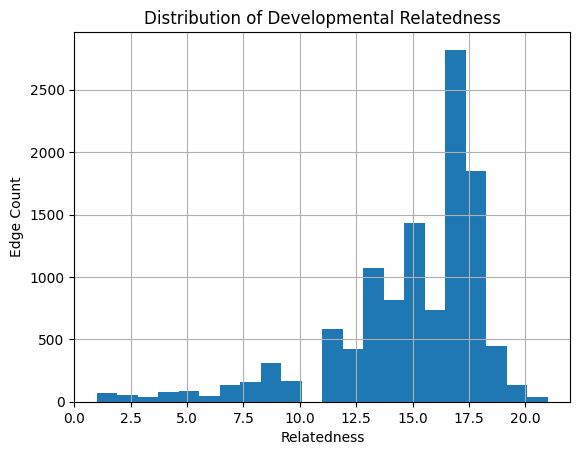

In [139]:
import matplotlib.pyplot as plt

df['Relatedness'].dropna().astype(int).hist(bins=22)
plt.xlabel("Relatedness")
plt.ylabel("Edge Count")
plt.title("Distribution of Developmental Relatedness")
plt.grid(True)
plt.show()


In [141]:
import pandas as pd

# === Load Primary Files ===
edges_df = pd.read_csv("merged_edges_with_relatedness.csv")
lineage_df = pd.read_csv("merged_lineage_table.csv")

print("🧠 Edges columns:", edges_df.columns.tolist())
print("🧬 Lineage columns:", lineage_df.columns.tolist())

# === Try to infer lineage neuron + lineage column names ===
# Case 1: ['Neuron', 'Lineage']
if 'Neuron' in lineage_df.columns and 'Lineage' in lineage_df.columns:
    lineage_src = lineage_df.rename(columns={'Neuron': 'Source', 'Lineage': 'Source_Lineage'})
    lineage_tgt = lineage_df.rename(columns={'Neuron': 'Target', 'Lineage': 'Target_Lineage'})

# Case 2: ['Name', 'Lineage'] or others
elif 'Name' in lineage_df.columns and 'Lineage' in lineage_df.columns:
    lineage_src = lineage_df.rename(columns={'Name': 'Source', 'Lineage': 'Source_Lineage'})
    lineage_tgt = lineage_df.rename(columns={'Name': 'Target', 'Lineage': 'Target_Lineage'})

else:
    raise ValueError("❌ Cannot find expected columns in merged_lineage_table.csv. Please inspect column names.")

# === Merge Source Lineage
merged = pd.merge(edges_df, lineage_src, on="Source", how="left")

# === Merge Target Lineage
merged = pd.merge(merged, lineage_tgt, on="Target", how="left")

# === Save Output
merged.to_csv("master_connectome_dataset.csv", index=False)
print("✅ Saved merged dataset to master_connectome_dataset.csv")


🧠 Edges columns: ['Source', 'Target', 'Type', 'SynapseCount', 'SourceFile', 'Relatedness']
🧬 Lineage columns: ['NeuronA', 'NeuronB', 'Relatedness']


ValueError: ❌ Cannot find expected columns in merged_lineage_table.csv. Please inspect column names.